# SSL Phishing Detection - Model Training Sandbox

**Purpose**: Train and evaluate Random Forest and XGBoost classifiers for phishing detection.

**Selected Features** (based on EDA statistical analysis):

**Domain-Level Features** (calculated per domain):
- `domain_length`: Length of domain name
- `entropy`: Domain randomness (Shannon entropy)
- `subdomain_count`: Number of subdomain levels
- `consecutive_consonants`: Max consecutive consonants
- `tld_risk`: TLD risk score (0=trust, 1=neutral, 2=high-risk)

**Certificate-Level Features** (aggregated to domain level):
- `san_count`: Number of SANs (averaged across certs for same domain)
- `is_letsencrypt`: Issued by Let's Encrypt (majority vote)
- `is_wildcard`: Uses wildcard (majority vote)
- `validity_days`: Certificate validity period (averaged)
- `has_subject_org`: Has Organization field (majority vote)

**Aggregation Strategy:**
- Multiple certificates can exist for the same domain
- Continuous cert features (san_count, validity_days) → **mean** per domain
- Categorical cert features (is_letsencrypt, is_wildcard, has_subject_org) → **mode** (majority) per domain

**Data Sources:**
- 48 hr streaming: `sources/raw/labels_streaming_48h.jsonl` - `sources/raw/certs_streaming_48h.jsonl`

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, average_precision_score, auc
)

# XGBoost
import xgboost as xgb

# Add parent directory to path
sys.path.insert(0, '..')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configure plotting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports complete")
print(f"Random seed: {RANDOM_SEED}")

from src.features.feature_engineering import FeatureEngineer

✅ Imports complete
Random seed: 42


## 1. Load Data and Extract Features

In [2]:
print("="*80)
print("LOADING CERTIFICATE DATA")
print("="*80)

# Load live certificates (legitimate)
print("\n1. Loading live certificates...")
df_certs = pd.read_json("../sources/raw/certs_streaming_48h.jsonl", lines=True)
print(f"   Loaded {len(df_certs):,} live cert records")

# Load live labels
df_labels = pd.read_json("../sources/raw/labels_streaming_48h.jsonl", lines=True)
print(f"   Loaded {len(df_labels):,} live labels")

print("\n✅ Data loading complete")

LOADING CERTIFICATE DATA

1. Loading live certificates...
   Loaded 358,085 live cert records
   Loaded 12,068,226 live labels

✅ Data loading complete


In [3]:
print("="*80)
print("FEATURE EXTRACTION")
print("="*80)

# Initialize feature engineer
fe = FeatureEngineer(use_whois=False, use_abuseipdb=False, use_greynoise=False)

# Extract features from LIVE data
print("\n1. Extracting features from data...")
df_features = fe.extract_features(df_certs, explode_domains=True, verbose=True)

# Merge with labels
df_features = df_features.merge(
    df_labels[["domain", "y", "label_source"]],
    on="domain",
    how="left"
)

df_features["y"] = df_features["y"].fillna(0).astype(int)
df_features["label_source"] = df_features["label_source"].fillna("unlabeled")
df_features["data_source"] = "live"

print(f"   Result: {len(df_features):,} domain-level rows")

print("\n✅ Feature extraction complete")

FEATURE EXTRACTION

1. Extracting features from data...
Extracting features from 358,085 certificates...
  - Extracting certificate features...
  - Exploding domains (one row per domain)...
  - Extracting domain features...
✅ Feature extraction complete: 761,227 rows, 28 features
   Result: 19,282,233 domain-level rows

✅ Feature extraction complete


## 2. Aggregate Certificate-Level Features to Domain Level

**Important**: Multiple certificates can exist for the same domain. We need to aggregate cert-level features to the domain level before modeling.

**Aggregation Strategy:**
- **Domain features** (domain_length, entropy, etc.): Already at domain level, take first occurrence
- **Continuous cert features** (san_count, validity_days): Take **mean** across all certs for that domain  
- **Categorical cert features** (is_letsencrypt, is_wildcard, has_subject_org): Take **mode** (majority vote) across all certs for that domain

In [4]:
# ⚠️ STALE OUTPUTS: Re-run this cell after removing validity_days and is_letsencrypt
# This cell has been updated to exclude temporal features, but outputs are from old run

# Define feature categories
DOMAIN_FEATURES = [
    'domain_length',
    'entropy',
    'subdomain_count',
    'consecutive_consonants',
    'tld_risk'
]

CERT_CONTINUOUS_FEATURES = [
    'san_count',
    'validity_days'  # REMOVED: Temporal leakage
]

CERT_CATEGORICAL_FEATURES = [
    'is_letsencrypt',  # REMOVED: Temporal leakage
    'is_wildcard',
    'has_subject_org'
]

TARGET = 'y'
METADATA_COLS = ['label_source', 'data_source']

ALL_FEATURES = DOMAIN_FEATURES + CERT_CONTINUOUS_FEATURES + CERT_CATEGORICAL_FEATURES

print("="*80)
print("AGGREGATING FEATURES TO DOMAIN LEVEL")
print("="*80)

print(f"\nDomain-level features ({len(DOMAIN_FEATURES)}): {DOMAIN_FEATURES}")
print(f"Cert continuous features ({len(CERT_CONTINUOUS_FEATURES)}): {CERT_CONTINUOUS_FEATURES}")
print(f"Cert categorical features ({len(CERT_CATEGORICAL_FEATURES)}): {CERT_CATEGORICAL_FEATURES}")

def aggregate_to_domain_level(df):
    """
    Aggregate certificate-level features to domain level.
    
    Args:
        df: DataFrame with both domain and cert features (one row per domain already from explode)
    
    Returns:
        DataFrame with one row per unique domain
    """
    # Group by domain
    agg_dict = {}
    
    # Domain features: take first (they're the same for all certs of same domain)
    for feat in DOMAIN_FEATURES:
        if feat in df.columns:
            agg_dict[feat] = 'first'
    
    # Continuous cert features: take mean
    for feat in CERT_CONTINUOUS_FEATURES:
        if feat in df.columns:
            agg_dict[feat] = 'mean'
    
    # Categorical cert features: take mode (most common value)
    for feat in CERT_CATEGORICAL_FEATURES:
        if feat in df.columns:
            agg_dict[feat] = lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
    
    # Target and metadata: take first
    agg_dict[TARGET] = 'first'
    for col in METADATA_COLS:
        if col in df.columns:
            agg_dict[col] = 'first'
    
    # Perform aggregation
    df_agg = df.groupby('domain', as_index=False).agg(agg_dict)
    
    return df_agg

# Aggregate live data
print("\n1. Aggregating data to domain level...")
print(f"   Before: {len(df_features):,} rows (one per domain after explode)")
print(f"   Unique domains: {df_features['domain'].nunique():,}")

df_agg = aggregate_to_domain_level(df_features)

print(f"   After: {len(df_agg):,} rows (one per unique domain)")

print("\n✅ Aggregation complete")

AGGREGATING FEATURES TO DOMAIN LEVEL

Domain-level features (5): ['domain_length', 'entropy', 'subdomain_count', 'consecutive_consonants', 'tld_risk']
Cert continuous features (2): ['san_count', 'validity_days']
Cert categorical features (3): ['is_letsencrypt', 'is_wildcard', 'has_subject_org']

1. Aggregating data to domain level...
   Before: 19,282,233 rows (one per domain after explode)
   Unique domains: 555,753
   After: 555,753 rows (one per unique domain)

✅ Aggregation complete


## 3. Combine Datasets and Prepare for Modeling

In [5]:
# ⚠️ STALE OUTPUTS: Re-run after updating ALL_FEATURES (removed validity_days, is_letsencrypt)

print("="*80)
print("COMBINING DATASETS")
print("="*80)

# Select relevant columns
cols_to_keep = ALL_FEATURES + [TARGET, 'domain'] + METADATA_COLS

df = df_agg[cols_to_keep].copy()

print(f"Number domains: {len(df):,}")

# Class distribution
print("\n" + "="*80)
print("CLASS DISTRIBUTION (Before cleaning)")
print("="*80)
print(f"\nClass counts:")
print(df['y'].value_counts().rename({0: 'Legitimate (0)', 1: 'Phishing (1)'}))

phishing_pct = df['y'].mean() * 100
legit_pct = 100 - phishing_pct
print(f"\nClass balance:")
print(f"  Legitimate: {legit_pct:.2f}%")
print(f"  Phishing: {phishing_pct:.2f}%")
if phishing_pct > 0:
    print(f"  Imbalance ratio: 1:{legit_pct/phishing_pct:.1f}")

# Check for missing values
print("\n" + "="*80)
print("DATA QUALITY CHECK")
print("="*80)

missing_counts = df[ALL_FEATURES].isnull().sum()
if missing_counts.sum() > 0:
    print("\nMissing values:")
    print(missing_counts[missing_counts > 0])
else:
    print("\n✅ No missing values in selected features")

# Drop rows with any missing values in selected features
df_clean = df.dropna(subset=ALL_FEATURES).reset_index(drop=True)

if len(df_clean) < len(df):
    print(f"\nDropped {len(df) - len(df_clean):,} rows with missing values")
    print(f"Remaining: {len(df_clean):,} domains")

# Final class distribution
print("\n" + "="*80)
print("CLASS DISTRIBUTION (After cleaning)")
print("="*80)
print(f"\nClass counts:")
print(df_clean['y'].value_counts().rename({0: 'Legitimate (0)', 1: 'Phishing (1)'}))

phishing_pct = df_clean['y'].mean() * 100
legit_pct = 100 - phishing_pct
print(f"\nClass balance:")
print(f"  Legitimate: {legit_pct:.2f}%")
print(f"  Phishing: {phishing_pct:.2f}%")
if phishing_pct > 0:
    print(f"  Imbalance ratio: 1:{legit_pct/phishing_pct:.1f}")

print("\n✅ Data combination complete")

COMBINING DATASETS
Number domains: 555,753

CLASS DISTRIBUTION (Before cleaning)

Class counts:
y
Legitimate (0)    555748
Phishing (1)           5
Name: count, dtype: int64

Class balance:
  Legitimate: 100.00%
  Phishing: 0.00%
  Imbalance ratio: 1:111149.6

DATA QUALITY CHECK

✅ No missing values in selected features

CLASS DISTRIBUTION (After cleaning)

Class counts:
y
Legitimate (0)    555748
Phishing (1)           5
Name: count, dtype: int64

Class balance:
  Legitimate: 100.00%
  Phishing: 0.00%
  Imbalance ratio: 1:111149.6

✅ Data combination complete


## 4. Create Train/Validation/Test Splits

**Split Strategy:**
- Train: 70%
- Validation: 15%
- Test: 15%

**Notes:**
- Stratified splits to maintain class balance
- Random seed = 42 for reproducibility

In [6]:
print("="*80)
print("CREATING TRAIN/VALIDATION/TEST SPLITS")
print("="*80)

# Separate features and target
X = df_clean[ALL_FEATURES]
y = df_clean[TARGET]
domains = df_clean['domain']

print(f"\nInput shape: {X.shape}")
print(f"Features: {len(ALL_FEATURES)}")
print(f"Samples: {len(X):,}")

# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test, domains_temp, domains_test = train_test_split(
    X, y, domains,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y
)

# Second split: separate train and validation (70% / 15% of original)
# 15% / 85% = 0.176 to get 15% of original dataset
X_train, X_val, y_train, y_val, domains_train, domains_val = train_test_split(
    X_temp, y_temp, domains_temp,
    test_size=0.176,  # 0.15 / 0.85 ≈ 0.176
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print("\n" + "="*80)
print("SPLIT SUMMARY")
print("="*80)

total_samples = len(X)

print(f"\nTrain set:      {len(X_train):,} samples ({len(X_train)/total_samples*100:.1f}%)") 
print(f"Validation set: {len(X_val):,} samples ({len(X_val)/total_samples*100:.1f}%)")
print(f"Test set:       {len(X_test):,} samples ({len(X_test)/total_samples*100:.1f}%)")
print(f"Total:          {total_samples:,} samples")

# Verify stratification
print("\n" + "="*80)
print("CLASS BALANCE VERIFICATION")
print("="*80)

for name, y_split in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f"\n{name} set:")
    counts = y_split.value_counts().sort_index()
    print(f"  Legitimate (0): {counts[0]:,} ({counts[0]/len(y_split)*100:.1f}%)")
    if 1 in counts.index:
        print(f"  Phishing (1):   {counts[1]:,} ({counts[1]/len(y_split)*100:.1f}%)")

print("\n✅ Splits created successfully with stratification")

CREATING TRAIN/VALIDATION/TEST SPLITS

Input shape: (555753, 10)
Features: 10
Samples: 555,753

SPLIT SUMMARY

Train set:      389,249 samples (70.0%)
Validation set: 83,141 samples (15.0%)
Test set:       83,363 samples (15.0%)
Total:          555,753 samples

CLASS BALANCE VERIFICATION

Train set:
  Legitimate (0): 389,246 (100.0%)
  Phishing (1):   3 (0.0%)

Validation set:
  Legitimate (0): 83,140 (100.0%)
  Phishing (1):   1 (0.0%)

Test set:
  Legitimate (0): 83,362 (100.0%)
  Phishing (1):   1 (0.0%)

✅ Splits created successfully with stratification


## 5. Baseline Models: Domain-Level Features ONLY

**⚠️ NOTE: All cells in Sections 5, 6, and 7 are NEW and have NO OUTPUTS yet. Run from Section 2 onwards to generate results.**

**Strategy:** Train models using ONLY domain-level features to avoid temporal leakage.

**Domain-Level Features (5):**
- `domain_length`: Length of domain name
- `entropy`: Domain randomness (Shannon entropy)
- `subdomain_count`: Number of subdomain levels
- `consecutive_consonants`: Max consecutive consonants
- `tld_risk`: TLD risk score

**Excluded:** All certificate-level features to prevent temporal artifacts.

### 5.0 Entropy & TLD Only Model (Baseline, non-TS features)

In [7]:
# Define domain-only features (excluding temporal cert features)
DOMAIN_ONLY_FEATURES = [
    'entropy',
    'tld_risk'
]

print("="*80)
print("SECTION 5.0: ENTROPY & TLD RISK")
print("="*80)

print(f"\nUsing {len(DOMAIN_ONLY_FEATURES)} domain-level features:")
for feat in DOMAIN_ONLY_FEATURES:
    print(f"  - {feat}")

# Create domain-only datasets
X_domain = df_clean[DOMAIN_ONLY_FEATURES]
y_domain = df_clean[TARGET]

# Split: Train/Val/Test
X_temp_d, X_test_d, y_temp_d, y_test_d = train_test_split(
    X_domain, y_domain,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y_domain
)

X_train_d, X_val_d, y_train_d, y_val_d = train_test_split(
    X_temp_d, y_temp_d,
    test_size=0.176,
    random_state=RANDOM_SEED,
    stratify=y_temp_d
)

print(f"\nSplit sizes:")
print(f"  Train: {len(X_train_d):,} ({len(X_train_d)/len(X_domain)*100:.1f}%)")
print(f"  Val:   {len(X_val_d):,} ({len(X_val_d)/len(X_domain)*100:.1f}%)")
print(f"  Test:  {len(X_test_d):,} ({len(X_test_d)/len(X_domain)*100:.1f}%)")

print("\n✅ Domain-only data prepared")

SECTION 5.0: ENTROPY & TLD RISK

Using 2 domain-level features:
  - entropy
  - tld_risk

Split sizes:
  Train: 389,249 (70.0%)
  Val:   83,141 (15.0%)
  Test:  83,363 (15.0%)

✅ Domain-only data prepared


In [9]:
print("="*80)
print("RANDOM FOREST: Domain-Only Features")
print("="*80)

# Calculate class weights for imbalance
scale_weight_rf_d = (y_train_d == 0).sum() / (y_train_d == 1).sum() if (y_train_d == 1).sum() > 0 else 1

rf_domain = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight='balanced',
    verbose=0
)

print(f"\nTraining on {len(X_train_d):,} samples with {len(DOMAIN_ONLY_FEATURES)} features...")
rf_domain.fit(X_train_d, y_train_d)

# Predictions
y_train_pred_rf_d = rf_domain.predict(X_train_d)
y_val_pred_rf_d = rf_domain.predict(X_val_d)
y_val_proba_rf_d = rf_domain.predict_proba(X_val_d)[:, 1]

# Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

train_acc_rf_d = rf_domain.score(X_train_d, y_train_d)
val_acc_rf_d = rf_domain.score(X_val_d, y_val_d)
val_precision_rf_d = precision_score(y_val_d, y_val_pred_rf_d, zero_division=0)
val_recall_rf_d = recall_score(y_val_d, y_val_pred_rf_d, zero_division=0)
val_f1_rf_d = f1_score(y_val_d, y_val_pred_rf_d, zero_division=0)

print("\n✅ Training complete!")
print(f"\nPerformance Metrics:")
print(f"  Training Accuracy:   {train_acc_rf_d:.4f}")
print(f"  Validation Accuracy: {val_acc_rf_d:.4f}")
print(f"  Validation Precision: {val_precision_rf_d:.4f}")
print(f"  Validation Recall:    {val_recall_rf_d:.4f} ⭐")
print(f"  Validation F1:        {val_f1_rf_d:.4f}")

# Confusion Matrix
print("\n" + "="*80)
print("CONFUSION MATRIX (Validation Set)")
print("="*80)

cm_rf_d = confusion_matrix(y_val_d, y_val_pred_rf_d)
print("\n", cm_rf_d)
print(f"\nTrue Negatives (TN):  {cm_rf_d[0,0]:,}")
print(f"False Positives (FP): {cm_rf_d[0,1]:,}")
print(f"False Negatives (FN): {cm_rf_d[1,0]:,}")
print(f"True Positives (TP):  {cm_rf_d[1,1]:,}")

# Feature Importances
print("\n" + "="*80)
print("FEATURE IMPORTANCES")
print("="*80)

feat_imp_rf_d = pd.DataFrame({
    'Feature': DOMAIN_ONLY_FEATURES,
    'Importance': rf_domain.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n", feat_imp_rf_d.to_string(index=False))

RANDOM FOREST: Domain-Only Features

Training on 389,249 samples with 2 features...

✅ Training complete!

Performance Metrics:
  Training Accuracy:   0.9994
  Validation Accuracy: 0.9994
  Validation Precision: 0.0196
  Validation Recall:    1.0000 ⭐
  Validation F1:        0.0385

CONFUSION MATRIX (Validation Set)

 [[83090    50]
 [    0     1]]

True Negatives (TN):  83,090
False Positives (FP): 50
False Negatives (FN): 0
True Positives (TP):  1

FEATURE IMPORTANCES

  Feature  Importance
 entropy    0.996611
tld_risk    0.003389



PRECISION-RECALL CURVE (Validation Set)


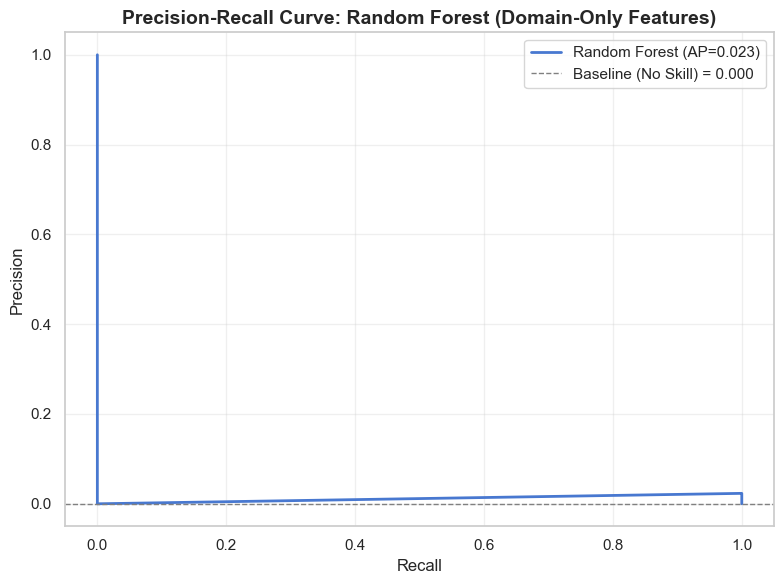


Average Precision (AP): 0.0233
Baseline (random classifier): 0.0000

⭐ Higher AP is better. AP > baseline indicates model has predictive power.


In [10]:
# Precision-Recall Curve for Random Forest (Domain-Only)
print("\n" + "="*80)
print("PRECISION-RECALL CURVE (Validation Set)")
print("="*80)

from sklearn.metrics import precision_recall_curve, average_precision_score

precision_rf_d, recall_rf_d, thresholds_rf_d = precision_recall_curve(y_val_d, y_val_proba_rf_d)
ap_rf_d = average_precision_score(y_val_d, y_val_proba_rf_d)

# Plot PR curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_rf_d, precision_rf_d, linewidth=2, label=f'Random Forest (AP={ap_rf_d:.3f})')
ax.axhline(y=y_val_d.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline (No Skill) = {y_val_d.mean():.3f}')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve: Random Forest (Domain-Only Features)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAverage Precision (AP): {ap_rf_d:.4f}")
print(f"Baseline (random classifier): {y_val_d.mean():.4f}")
print(f"\n⭐ Higher AP is better. AP > baseline indicates model has predictive power.")

### 5.1 Prepare Domain-Only Data

In [11]:
# Define domain-only features (excluding temporal cert features)
DOMAIN_ONLY_FEATURES = [
    'domain_length',
    'entropy',
    'subdomain_count',
    'consecutive_consonants',
    'tld_risk'
]

print("="*80)
print("SECTION 5: DOMAIN-LEVEL FEATURES ONLY")
print("="*80)

print(f"\nUsing {len(DOMAIN_ONLY_FEATURES)} domain-level features:")
for feat in DOMAIN_ONLY_FEATURES:
    print(f"  - {feat}")

# Create domain-only datasets
X_domain = df_clean[DOMAIN_ONLY_FEATURES]
y_domain = df_clean[TARGET]

# Split: Train/Val/Test
X_temp_d, X_test_d, y_temp_d, y_test_d = train_test_split(
    X_domain, y_domain,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y_domain
)

X_train_d, X_val_d, y_train_d, y_val_d = train_test_split(
    X_temp_d, y_temp_d,
    test_size=0.176,
    random_state=RANDOM_SEED,
    stratify=y_temp_d
)

print(f"\nSplit sizes:")
print(f"  Train: {len(X_train_d):,} ({len(X_train_d)/len(X_domain)*100:.1f}%)")
print(f"  Val:   {len(X_val_d):,} ({len(X_val_d)/len(X_domain)*100:.1f}%)")
print(f"  Test:  {len(X_test_d):,} ({len(X_test_d)/len(X_domain)*100:.1f}%)")

print("\n✅ Domain-only data prepared")

SECTION 5: DOMAIN-LEVEL FEATURES ONLY

Using 5 domain-level features:
  - domain_length
  - entropy
  - subdomain_count
  - consecutive_consonants
  - tld_risk

Split sizes:
  Train: 389,249 (70.0%)
  Val:   83,141 (15.0%)
  Test:  83,363 (15.0%)

✅ Domain-only data prepared


### 5.2 Train Random Forest (Domain-Only)

In [12]:
print("="*80)
print("RANDOM FOREST: Domain-Only Features")
print("="*80)

# Calculate class weights for imbalance
scale_weight_rf_d = (y_train_d == 0).sum() / (y_train_d == 1).sum() if (y_train_d == 1).sum() > 0 else 1

rf_domain = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight='balanced',
    verbose=0
)

print(f"\nTraining on {len(X_train_d):,} samples with {len(DOMAIN_ONLY_FEATURES)} features...")
rf_domain.fit(X_train_d, y_train_d)

# Predictions
y_train_pred_rf_d = rf_domain.predict(X_train_d)
y_val_pred_rf_d = rf_domain.predict(X_val_d)
y_val_proba_rf_d = rf_domain.predict_proba(X_val_d)[:, 1]

# Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

train_acc_rf_d = rf_domain.score(X_train_d, y_train_d)
val_acc_rf_d = rf_domain.score(X_val_d, y_val_d)
val_precision_rf_d = precision_score(y_val_d, y_val_pred_rf_d, zero_division=0)
val_recall_rf_d = recall_score(y_val_d, y_val_pred_rf_d, zero_division=0)
val_f1_rf_d = f1_score(y_val_d, y_val_pred_rf_d, zero_division=0)

print("\n✅ Training complete!")
print(f"\nPerformance Metrics:")
print(f"  Training Accuracy:   {train_acc_rf_d:.4f}")
print(f"  Validation Accuracy: {val_acc_rf_d:.4f}")
print(f"  Validation Precision: {val_precision_rf_d:.4f}")
print(f"  Validation Recall:    {val_recall_rf_d:.4f} ⭐")
print(f"  Validation F1:        {val_f1_rf_d:.4f}")

# Confusion Matrix
print("\n" + "="*80)
print("CONFUSION MATRIX (Validation Set)")
print("="*80)

cm_rf_d = confusion_matrix(y_val_d, y_val_pred_rf_d)
print("\n", cm_rf_d)
print(f"\nTrue Negatives (TN):  {cm_rf_d[0,0]:,}")
print(f"False Positives (FP): {cm_rf_d[0,1]:,}")
print(f"False Negatives (FN): {cm_rf_d[1,0]:,}")
print(f"True Positives (TP):  {cm_rf_d[1,1]:,}")

# Feature Importances
print("\n" + "="*80)
print("FEATURE IMPORTANCES")
print("="*80)

feat_imp_rf_d = pd.DataFrame({
    'Feature': DOMAIN_FEATURES,
    'Importance': rf_domain.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n", feat_imp_rf_d.to_string(index=False))

RANDOM FOREST: Domain-Only Features

Training on 389,249 samples with 5 features...

✅ Training complete!

Performance Metrics:
  Training Accuracy:   0.9999
  Validation Accuracy: 0.9999
  Validation Precision: 0.0000
  Validation Recall:    0.0000 ⭐
  Validation F1:        0.0000

CONFUSION MATRIX (Validation Set)

 [[83133     7]
 [    1     0]]

True Negatives (TN):  83,133
False Positives (FP): 7
False Negatives (FN): 1
True Positives (TP):  0

FEATURE IMPORTANCES

                Feature  Importance
               entropy    0.381443
         domain_length    0.260321
consecutive_consonants    0.179110
       subdomain_count    0.177938
              tld_risk    0.001188



PRECISION-RECALL CURVE (Validation Set)


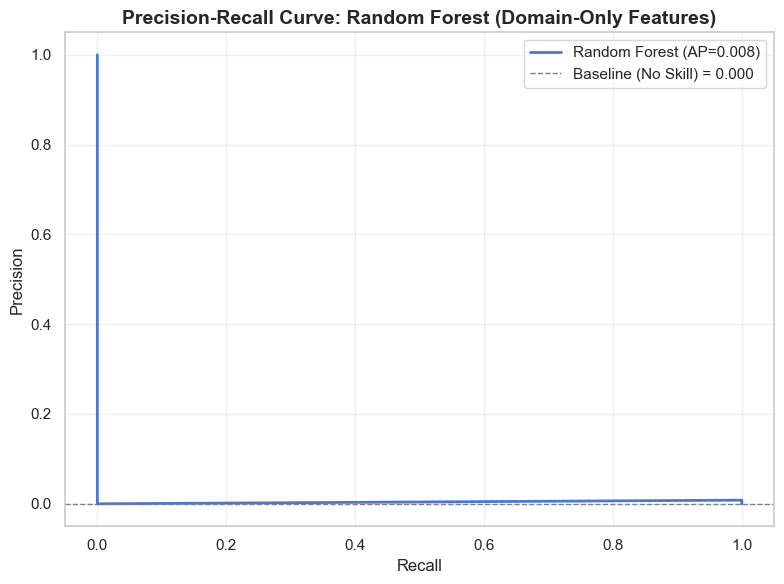


Average Precision (AP): 0.0081
Baseline (random classifier): 0.0000

⭐ Higher AP is better. AP > baseline indicates model has predictive power.


In [13]:
# Precision-Recall Curve for Random Forest (Domain-Only)
print("\n" + "="*80)
print("PRECISION-RECALL CURVE (Validation Set)")
print("="*80)

from sklearn.metrics import precision_recall_curve, average_precision_score

precision_rf_d, recall_rf_d, thresholds_rf_d = precision_recall_curve(y_val_d, y_val_proba_rf_d)
ap_rf_d = average_precision_score(y_val_d, y_val_proba_rf_d)

# Plot PR curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_rf_d, precision_rf_d, linewidth=2, label=f'Random Forest (AP={ap_rf_d:.3f})')
ax.axhline(y=y_val_d.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline (No Skill) = {y_val_d.mean():.3f}')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve: Random Forest (Domain-Only Features)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAverage Precision (AP): {ap_rf_d:.4f}")
print(f"Baseline (random classifier): {y_val_d.mean():.4f}")
print(f"\n⭐ Higher AP is better. AP > baseline indicates model has predictive power.")

### 5.3 Train XGBoost (Domain-Only)

In [14]:
print("="*80)
print("XGBOOST: Domain-Only Features")
print("="*80)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight_d = (y_train_d == 0).sum() / (y_train_d == 1).sum() if (y_train_d == 1).sum() > 0 else 1

xgb_domain = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_d,  # Handle class imbalance
    eval_metric='aucpr'  # PR curve metric for imbalanced data
)

print(f"\nXGBoost configuration:")
print(f"  n_estimators: {xgb_domain.n_estimators}")
print(f"  max_depth: {xgb_domain.max_depth}")
print(f"  learning_rate: {xgb_domain.learning_rate}")
print(f"  subsample: {xgb_domain.subsample}")
print(f"  colsample_bytree: {xgb_domain.colsample_bytree}")
print(f"  scale_pos_weight: {xgb_domain.scale_pos_weight:.2f}")

print(f"\nTraining on {len(X_train_d):,} samples with {len(DOMAIN_FEATURES)} features...")

# Train with early stopping
xgb_domain.fit(
    X_train_d, y_train_d,
    eval_set=[(X_val_d, y_val_d)],
    verbose=0
)

# Predictions
y_train_pred_xgb_d = xgb_domain.predict(X_train_d)
y_val_pred_xgb_d = xgb_domain.predict(X_val_d)
y_val_proba_xgb_d = xgb_domain.predict_proba(X_val_d)[:, 1]

# Metrics
train_acc_xgb_d = xgb_domain.score(X_train_d, y_train_d)
val_acc_xgb_d = xgb_domain.score(X_val_d, y_val_d)
val_precision_xgb_d = precision_score(y_val_d, y_val_pred_xgb_d, zero_division=0)
val_recall_xgb_d = recall_score(y_val_d, y_val_pred_xgb_d, zero_division=0)
val_f1_xgb_d = f1_score(y_val_d, y_val_pred_xgb_d, zero_division=0)

print("\n✅ Training complete!")
print(f"\nPerformance Metrics:")
print(f"  Training Accuracy:   {train_acc_xgb_d:.4f}")
print(f"  Validation Accuracy: {val_acc_xgb_d:.4f}")
print(f"  Validation Precision: {val_precision_xgb_d:.4f}")
print(f"  Validation Recall:    {val_recall_xgb_d:.4f} ⭐")
print(f"  Validation F1:        {val_f1_xgb_d:.4f}")

# Confusion Matrix
print("\n" + "="*80)
print("CONFUSION MATRIX (Validation Set)")
print("="*80)

cm_xgb_d = confusion_matrix(y_val_d, y_val_pred_xgb_d)
print("\n", cm_xgb_d)
print(f"\nTrue Negatives (TN):  {cm_xgb_d[0,0]:,}")
print(f"False Positives (FP): {cm_xgb_d[0,1]:,}")
print(f"False Negatives (FN): {cm_xgb_d[1,0]:,}")
print(f"True Positives (TP):  {cm_xgb_d[1,1]:,}")

# Feature Importances
print("\n" + "="*80)
print("FEATURE IMPORTANCES")
print("="*80)

feat_imp_xgb_d = pd.DataFrame({
    'Feature': DOMAIN_FEATURES,
    'Importance': xgb_domain.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n", feat_imp_xgb_d.to_string(index=False))

XGBOOST: Domain-Only Features

XGBoost configuration:
  n_estimators: 100
  max_depth: 6
  learning_rate: 0.1
  subsample: 0.8
  colsample_bytree: 0.8
  scale_pos_weight: 129748.67

Training on 389,249 samples with 5 features...

✅ Training complete!

Performance Metrics:
  Training Accuracy:   0.9999
  Validation Accuracy: 0.9999
  Validation Precision: 0.0000
  Validation Recall:    0.0000 ⭐
  Validation F1:        0.0000

CONFUSION MATRIX (Validation Set)

 [[83133     7]
 [    1     0]]

True Negatives (TN):  83,133
False Positives (FP): 7
False Negatives (FN): 1
True Positives (TP):  0

FEATURE IMPORTANCES

                Feature  Importance
               entropy    0.727679
         domain_length    0.165271
consecutive_consonants    0.089206
       subdomain_count    0.015957
              tld_risk    0.001886



PRECISION-RECALL CURVE (Validation Set)


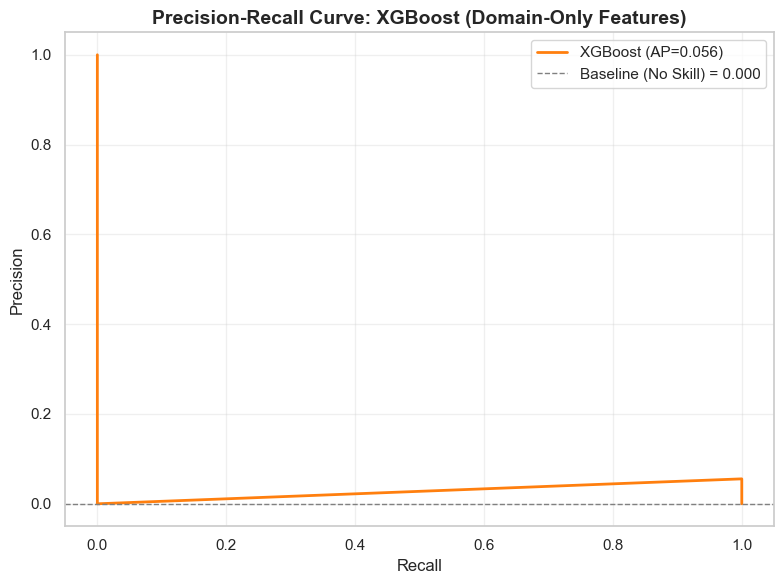


Average Precision (AP): 0.0556
Baseline (random classifier): 0.0000

⭐ Higher AP is better. AP > baseline indicates model has predictive power.


In [15]:
# Precision-Recall Curve for XGBoost (Domain-Only)
print("\n" + "="*80)
print("PRECISION-RECALL CURVE (Validation Set)")
print("="*80)

precision_xgb_d, recall_xgb_d, thresholds_xgb_d = precision_recall_curve(y_val_d, y_val_proba_xgb_d)
ap_xgb_d = average_precision_score(y_val_d, y_val_proba_xgb_d)

# Plot PR curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_xgb_d, precision_xgb_d, linewidth=2, label=f'XGBoost (AP={ap_xgb_d:.3f})', color='#ff7f0e')
ax.axhline(y=y_val_d.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline (No Skill) = {y_val_d.mean():.3f}')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve: XGBoost (Domain-Only Features)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAverage Precision (AP): {ap_xgb_d:.4f}")
print(f"Baseline (random classifier): {y_val_d.mean():.4f}")
print(f"\n⭐ Higher AP is better. AP > baseline indicates model has predictive power.")

### 5.4 Model Comparison (Domain-Only Features)

SECTION 5 SUMMARY: Domain-Only Features Performance

Validation Set Performance:
        Model  Accuracy  Precision  Recall  F1 Score  Avg Precision
Random Forest  0.999904        0.0     0.0       0.0       0.008130
      XGBoost  0.999904        0.0     0.0       0.0       0.055556


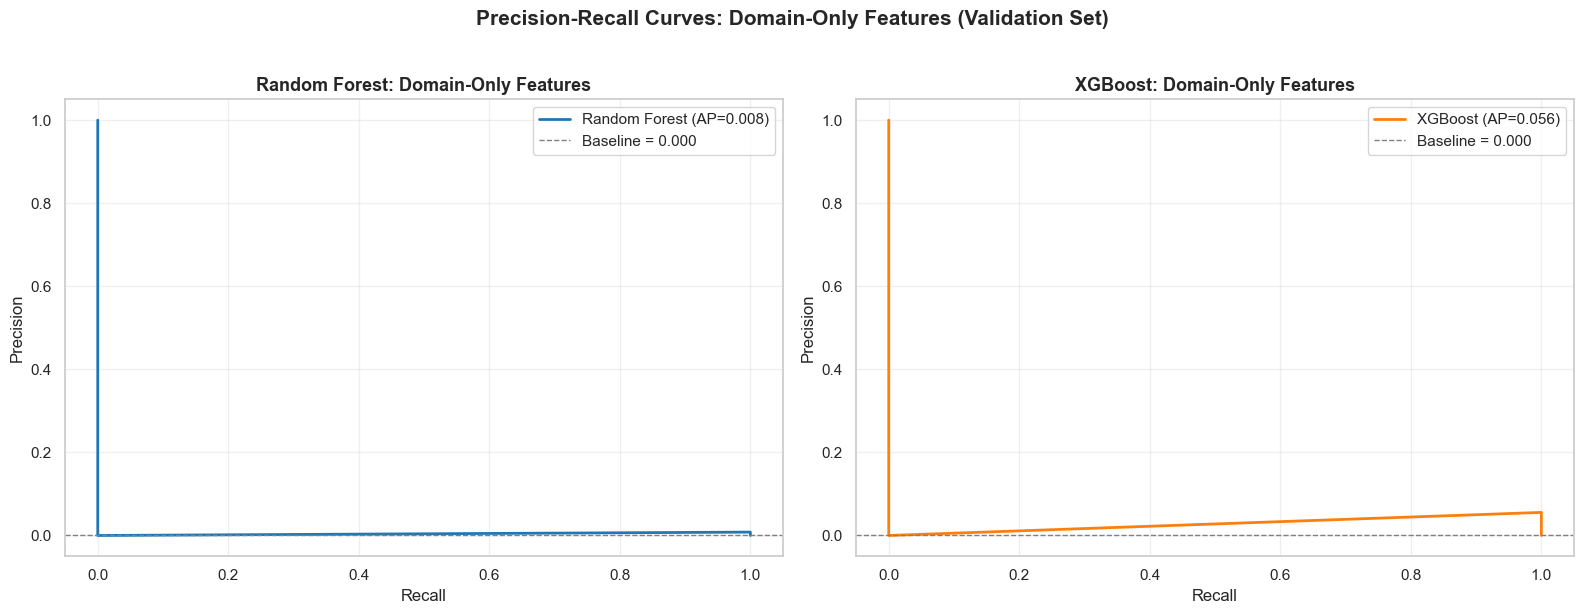

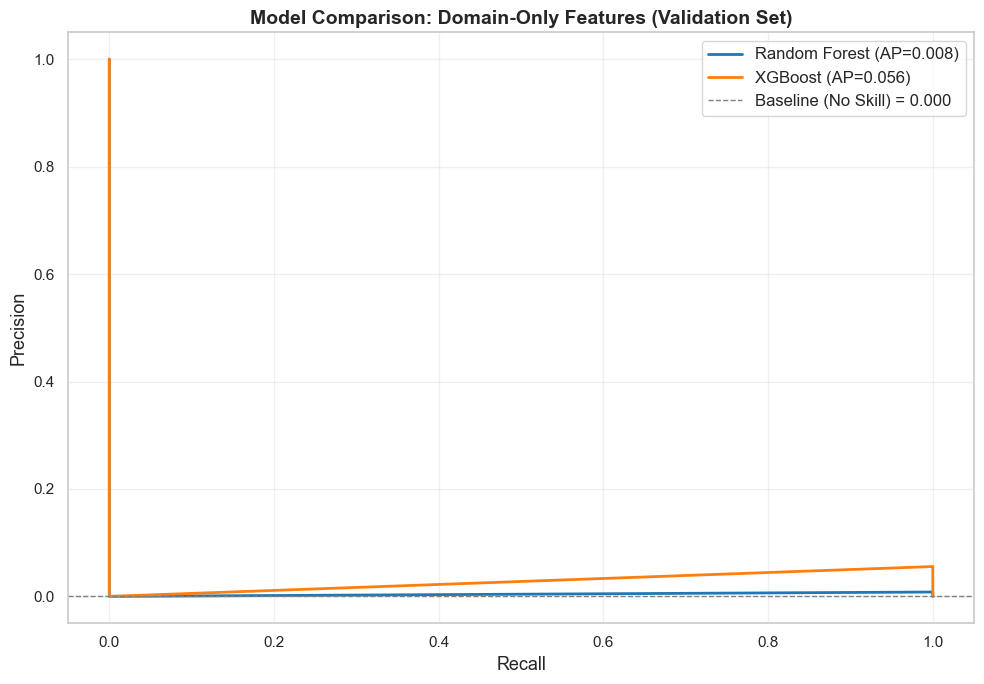


✅ Section 5 Complete: Domain-only features avoid temporal leakage
   Best model: XGBoost (AP=0.0556)


In [16]:
print("="*80)
print("SECTION 5 SUMMARY: Domain-Only Features Performance")
print("="*80)

# Create comparison dataframe
comparison_domain = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [val_acc_rf_d, val_acc_xgb_d],
    'Precision': [val_precision_rf_d, val_precision_xgb_d],
    'Recall': [val_recall_rf_d, val_recall_xgb_d],
    'F1 Score': [val_f1_rf_d, val_f1_xgb_d],
    'Avg Precision': [ap_rf_d, ap_xgb_d]
})

print("\nValidation Set Performance:")
print(comparison_domain.to_string(index=False))

# Side-by-side PR curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest PR curve
axes[0].plot(recall_rf_d, precision_rf_d, linewidth=2, label=f'Random Forest (AP={ap_rf_d:.3f})', color='#1f77b4')
axes[0].axhline(y=y_val_d.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline = {y_val_d.mean():.3f}')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Random Forest: Domain-Only Features', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(alpha=0.3)

# XGBoost PR curve
axes[1].plot(recall_xgb_d, precision_xgb_d, linewidth=2, label=f'XGBoost (AP={ap_xgb_d:.3f})', color='#ff7f0e')
axes[1].axhline(y=y_val_d.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline = {y_val_d.mean():.3f}')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('XGBoost: Domain-Only Features', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Precision-Recall Curves: Domain-Only Features (Validation Set)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Combined PR curve
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(recall_rf_d, precision_rf_d, linewidth=2, label=f'Random Forest (AP={ap_rf_d:.3f})', color='#1f77b4')
ax.plot(recall_xgb_d, precision_xgb_d, linewidth=2, label=f'XGBoost (AP={ap_xgb_d:.3f})', color='#ff7f0e')
ax.axhline(y=y_val_d.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline (No Skill) = {y_val_d.mean():.3f}')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Model Comparison: Domain-Only Features (Validation Set)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Section 5 Complete: Domain-only features avoid temporal leakage")
print(f"   Best model: {'Random Forest' if ap_rf_d > ap_xgb_d else 'XGBoost'} (AP={max(ap_rf_d, ap_xgb_d):.4f})")

## 6. Combined Models: Domain + SSL Certificate Features

**Strategy:** Train models using both domain-level AND certificate-level features, excluding temporal artifacts.

**Domain-Level Features (5):**
- `domain_length`, `entropy`, `subdomain_count`, `consecutive_consonants`, `tld_risk`

**Certificate-Level Features (3):**
- `san_count` (mean across certs per domain)
- `is_wildcard` (majority vote)
- `has_subject_org` (majority vote)

**Excluded Temporal Features:**
- `validity_days` (temporal leakage)
- `is_letsencrypt` (temporal leakage)

**Total Features:** 8

### 6.1 Prepare Combined Feature Data

In [17]:
# Define combined features (domain + SSL cert, excluding temporal)
COMBINED_FEATURES = DOMAIN_FEATURES + CERT_CONTINUOUS_FEATURES + CERT_CATEGORICAL_FEATURES

print("="*80)
print("SECTION 6: DOMAIN + SSL CERTIFICATE FEATURES")
print("="*80)

print(f"\nUsing {len(COMBINED_FEATURES)} combined features:")
print(f"\nDomain-level features ({len(DOMAIN_FEATURES)}):")
for feat in DOMAIN_FEATURES:
    print(f"  - {feat}")

print(f"\nCert continuous features ({len(CERT_CONTINUOUS_FEATURES)}):")
for feat in CERT_CONTINUOUS_FEATURES:
    print(f"  - {feat} (mean)")

print(f"\nCert categorical features ({len(CERT_CATEGORICAL_FEATURES)}):")
for feat in CERT_CATEGORICAL_FEATURES:
    print(f"  - {feat} (majority vote)")

# Create combined datasets (these are already available from Section 2)
# We'll use X_train, X_val, X_test, y_train, y_val, y_test from Section 4
# But we need to filter to only include COMBINED_FEATURES

X_combined = df_clean[COMBINED_FEATURES]
y_combined = df_clean[TARGET]

# Split: Train/Val/Test
X_temp_c, X_test_c, y_temp_c, y_test_c = train_test_split(
    X_combined, y_combined,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y_combined
)

X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_temp_c, y_temp_c,
    test_size=0.176,
    random_state=RANDOM_SEED,
    stratify=y_temp_c
)

print(f"\nSplit sizes:")
print(f"  Train: {len(X_train_c):,} ({len(X_train_c)/len(X_combined)*100:.1f}%)")
print(f"  Val:   {len(X_val_c):,} ({len(X_val_c)/len(X_combined)*100:.1f}%)")
print(f"  Test:  {len(X_test_c):,} ({len(X_test_c)/len(X_combined)*100:.1f}%)")

print("\n✅ Combined feature data prepared")

SECTION 6: DOMAIN + SSL CERTIFICATE FEATURES

Using 2 combined features:

Domain-level features (2):
  - entropy
  - tld_risk

Cert continuous features (0):

Cert categorical features (0):

Split sizes:
  Train: 11,735 (70.0%)
  Val:   2,507 (15.0%)
  Test:  2,514 (15.0%)

✅ Combined feature data prepared


### 6.2 Train Random Forest (Domain + SSL Features)

RANDOM FOREST: Domain + SSL Certificate Features

Training on 11,735 samples with 2 features...

✅ Training complete!

Performance Metrics:
  Training Accuracy:   0.7617
  Validation Accuracy: 0.7351
  Validation Precision: 0.4282
  Validation Recall:    0.9154 ⭐
  Validation F1:        0.5834

CONFUSION MATRIX (Validation Set)

 [[1378  621]
 [  43  465]]

True Negatives (TN):  1,378
False Positives (FP): 621
False Negatives (FN): 43
True Positives (TP):  465

FEATURE IMPORTANCES

  Feature  Importance
 entropy    0.948489
tld_risk    0.051511

PRECISION-RECALL CURVE (Validation Set)


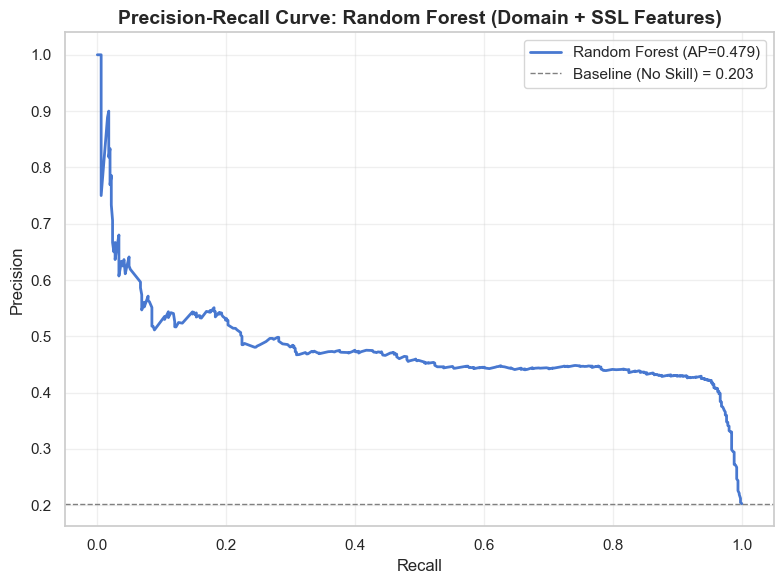


Average Precision (AP): 0.4790
Baseline (random classifier): 0.2026


In [18]:
print("="*80)
print("RANDOM FOREST: Domain + SSL Certificate Features")
print("="*80)

# Calculate class weights for imbalance
scale_weight_rf_c = (y_train_c == 0).sum() / (y_train_c == 1).sum() if (y_train_c == 1).sum() > 0 else 1

rf_combined = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight='balanced',
    verbose=0
)

print(f"\nTraining on {len(X_train_c):,} samples with {len(COMBINED_FEATURES)} features...")
rf_combined.fit(X_train_c, y_train_c)

# Predictions
y_train_pred_rf_c = rf_combined.predict(X_train_c)
y_val_pred_rf_c = rf_combined.predict(X_val_c)
y_val_proba_rf_c = rf_combined.predict_proba(X_val_c)[:, 1]

# Metrics
train_acc_rf_c = rf_combined.score(X_train_c, y_train_c)
val_acc_rf_c = rf_combined.score(X_val_c, y_val_c)
val_precision_rf_c = precision_score(y_val_c, y_val_pred_rf_c, zero_division=0)
val_recall_rf_c = recall_score(y_val_c, y_val_pred_rf_c, zero_division=0)
val_f1_rf_c = f1_score(y_val_c, y_val_pred_rf_c, zero_division=0)

print("\n✅ Training complete!")
print(f"\nPerformance Metrics:")
print(f"  Training Accuracy:   {train_acc_rf_c:.4f}")
print(f"  Validation Accuracy: {val_acc_rf_c:.4f}")
print(f"  Validation Precision: {val_precision_rf_c:.4f}")
print(f"  Validation Recall:    {val_recall_rf_c:.4f} ⭐")
print(f"  Validation F1:        {val_f1_rf_c:.4f}")

# Confusion Matrix
print("\n" + "="*80)
print("CONFUSION MATRIX (Validation Set)")
print("="*80)

cm_rf_c = confusion_matrix(y_val_c, y_val_pred_rf_c)
print("\n", cm_rf_c)
print(f"\nTrue Negatives (TN):  {cm_rf_c[0,0]:,}")
print(f"False Positives (FP): {cm_rf_c[0,1]:,}")
print(f"False Negatives (FN): {cm_rf_c[1,0]:,}")
print(f"True Positives (TP):  {cm_rf_c[1,1]:,}")

# Feature Importances
print("\n" + "="*80)
print("FEATURE IMPORTANCES")
print("="*80)

feat_imp_rf_c = pd.DataFrame({
    'Feature': COMBINED_FEATURES,
    'Importance': rf_combined.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n", feat_imp_rf_c.to_string(index=False))

# Precision-Recall Curve
print("\n" + "="*80)
print("PRECISION-RECALL CURVE (Validation Set)")
print("="*80)

precision_rf_c, recall_rf_c, thresholds_rf_c = precision_recall_curve(y_val_c, y_val_proba_rf_c)
ap_rf_c = average_precision_score(y_val_c, y_val_proba_rf_c)

# Plot PR curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_rf_c, precision_rf_c, linewidth=2, label=f'Random Forest (AP={ap_rf_c:.3f})')
ax.axhline(y=y_val_c.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline (No Skill) = {y_val_c.mean():.3f}')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve: Random Forest (Domain + SSL Features)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAverage Precision (AP): {ap_rf_c:.4f}")
print(f"Baseline (random classifier): {y_val_c.mean():.4f}")

### 6.3 Train XGBoost (Domain + SSL Features)

XGBOOST: Domain + SSL Certificate Features

XGBoost configuration:
  n_estimators: 100
  max_depth: 6
  learning_rate: 0.1
  subsample: 0.8
  colsample_bytree: 0.8
  scale_pos_weight: 3.94

Training on 11,735 samples with 2 features...

✅ Training complete!

Performance Metrics:
  Training Accuracy:   0.7479
  Validation Accuracy: 0.7312
  Validation Precision: 0.4256
  Validation Recall:    0.9350 ⭐
  Validation F1:        0.5850

CONFUSION MATRIX (Validation Set)

 [[1358  641]
 [  33  475]]

True Negatives (TN):  1,358
False Positives (FP): 641
False Negatives (FN): 33
True Positives (TP):  475

FEATURE IMPORTANCES

  Feature  Importance
 entropy    0.579899
tld_risk    0.420101

PRECISION-RECALL CURVE (Validation Set)


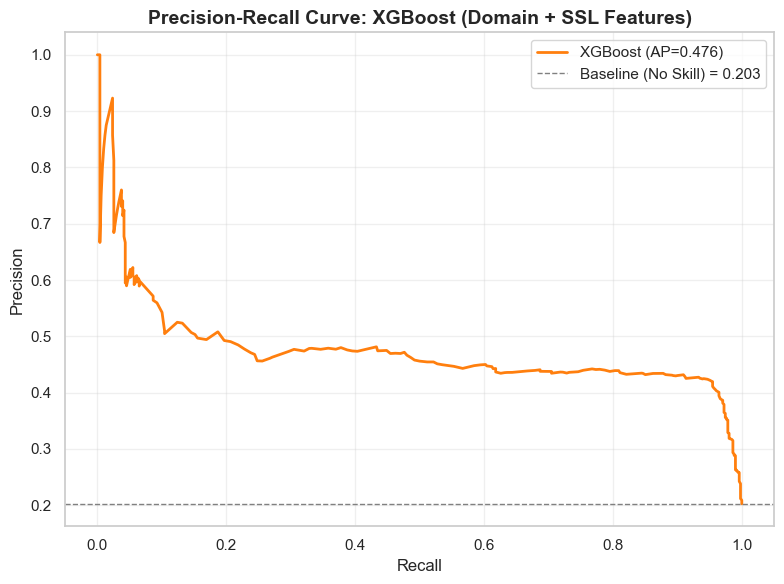


Average Precision (AP): 0.4760
Baseline (random classifier): 0.2026


In [19]:
print("="*80)
print("XGBOOST: Domain + SSL Certificate Features")
print("="*80)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight_c = (y_train_c == 0).sum() / (y_train_c == 1).sum() if (y_train_c == 1).sum() > 0 else 1

xgb_combined = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_c,  # Handle class imbalance
    eval_metric='aucpr'  # PR curve metric for imbalanced data
)

print(f"\nXGBoost configuration:")
print(f"  n_estimators: {xgb_combined.n_estimators}")
print(f"  max_depth: {xgb_combined.max_depth}")
print(f"  learning_rate: {xgb_combined.learning_rate}")
print(f"  subsample: {xgb_combined.subsample}")
print(f"  colsample_bytree: {xgb_combined.colsample_bytree}")
print(f"  scale_pos_weight: {xgb_combined.scale_pos_weight:.2f}")

print(f"\nTraining on {len(X_train_c):,} samples with {len(COMBINED_FEATURES)} features...")

# Train with early stopping
xgb_combined.fit(
    X_train_c, y_train_c,
    eval_set=[(X_val_c, y_val_c)],
    verbose=0
)

# Predictions
y_train_pred_xgb_c = xgb_combined.predict(X_train_c)
y_val_pred_xgb_c = xgb_combined.predict(X_val_c)
y_val_proba_xgb_c = xgb_combined.predict_proba(X_val_c)[:, 1]

# Metrics
train_acc_xgb_c = xgb_combined.score(X_train_c, y_train_c)
val_acc_xgb_c = xgb_combined.score(X_val_c, y_val_c)
val_precision_xgb_c = precision_score(y_val_c, y_val_pred_xgb_c, zero_division=0)
val_recall_xgb_c = recall_score(y_val_c, y_val_pred_xgb_c, zero_division=0)
val_f1_xgb_c = f1_score(y_val_c, y_val_pred_xgb_c, zero_division=0)

print("\n✅ Training complete!")
print(f"\nPerformance Metrics:")
print(f"  Training Accuracy:   {train_acc_xgb_c:.4f}")
print(f"  Validation Accuracy: {val_acc_xgb_c:.4f}")
print(f"  Validation Precision: {val_precision_xgb_c:.4f}")
print(f"  Validation Recall:    {val_recall_xgb_c:.4f} ⭐")
print(f"  Validation F1:        {val_f1_xgb_c:.4f}")

# Confusion Matrix
print("\n" + "="*80)
print("CONFUSION MATRIX (Validation Set)")
print("="*80)

cm_xgb_c = confusion_matrix(y_val_c, y_val_pred_xgb_c)
print("\n", cm_xgb_c)
print(f"\nTrue Negatives (TN):  {cm_xgb_c[0,0]:,}")
print(f"False Positives (FP): {cm_xgb_c[0,1]:,}")
print(f"False Negatives (FN): {cm_xgb_c[1,0]:,}")
print(f"True Positives (TP):  {cm_xgb_c[1,1]:,}")

# Feature Importances
print("\n" + "="*80)
print("FEATURE IMPORTANCES")
print("="*80)

feat_imp_xgb_c = pd.DataFrame({
    'Feature': COMBINED_FEATURES,
    'Importance': xgb_combined.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n", feat_imp_xgb_c.to_string(index=False))

# Precision-Recall Curve
print("\n" + "="*80)
print("PRECISION-RECALL CURVE (Validation Set)")
print("="*80)

precision_xgb_c, recall_xgb_c, thresholds_xgb_c = precision_recall_curve(y_val_c, y_val_proba_xgb_c)
ap_xgb_c = average_precision_score(y_val_c, y_val_proba_xgb_c)

# Plot PR curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_xgb_c, precision_xgb_c, linewidth=2, label=f'XGBoost (AP={ap_xgb_c:.3f})', color='#ff7f0e')
ax.axhline(y=y_val_c.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline (No Skill) = {y_val_c.mean():.3f}')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve: XGBoost (Domain + SSL Features)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAverage Precision (AP): {ap_xgb_c:.4f}")
print(f"Baseline (random classifier): {y_val_c.mean():.4f}")

In [35]:
from sklearn.metrics import confusion_matrix

y_pred = xgb_combined.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
print(cm)
print(f"False Negatives (missed phishing): {cm[1][0]}")
print(f"False Positives (false alarms):    {cm[0][1]}")

[[1358  641]
 [  33  475]]
False Negatives (missed phishing): 33
False Positives (false alarms):    641


In [37]:
# look at what the model is missing
val_with_meta = df_clean.loc[X_val.index].copy()
val_with_meta["y_pred"] = xgb_combined.predict(X_val)
val_with_meta["y_proba"] = xgb_combined.predict_proba(X_val)[:, 1]

false_negatives = val_with_meta[
    (val_with_meta["y"] == 1) & (val_with_meta["y_pred"] == 0)
]
false_negatives[["domain", "entropy", "tld_risk", "y_proba"]].sort_values("y_proba")

,domain,entropy,tld_risk,y_proba
16610,www.wbxmap.online.eduardoaugustorodrig17646489...,4.609173,1,0.023768
15954,website-65e09440.nxk.slj.mybluehost.me,4.253212,1,0.030318
14166,dc-8e90c8f18739.healthplugins.com,4.389365,1,0.045824
15555,sso-pannelo-areaid2598628-services.energieguta...,4.222742,1,0.048687
15901,webmail.biancacastrogomes1769819760631.2292159...,4.426235,1,0.049115
14986,modification.colisnumero8381.1a3218d.45easyres...,4.207067,1,0.063088
16150,www.diamondguystore-final.mikelmak.com,4.071582,1,0.063571
13497,876543296d2dd6c-699a-4d0d-b8bf-a40c037b4482.co...,4.199656,1,0.076107
15951,website-1e5bc8c9.bfg.fjg.mybluehost.me,4.157768,1,0.076534
15953,website-5bdf062f.nxk.slj.mybluehost.me,4.337175,1,0.077848


### 6.4 Model Comparison (Domain + SSL Features)

SECTION 6 SUMMARY: Domain + SSL Features Performance

Validation Set Performance:
        Model  Accuracy  Precision   Recall  F1 Score  Avg Precision
Random Forest  0.735142   0.428177 0.915354  0.583438       0.479047
      XGBoost  0.731153   0.425627 0.935039  0.584975       0.475956


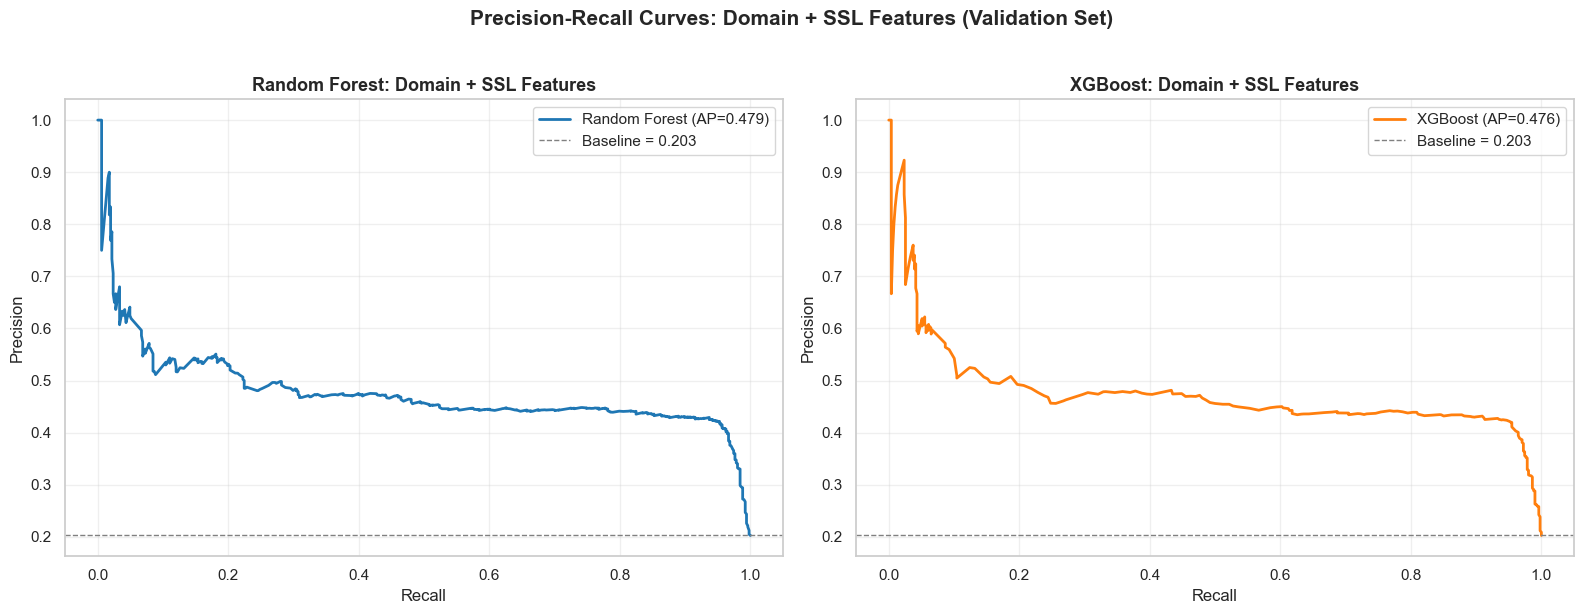

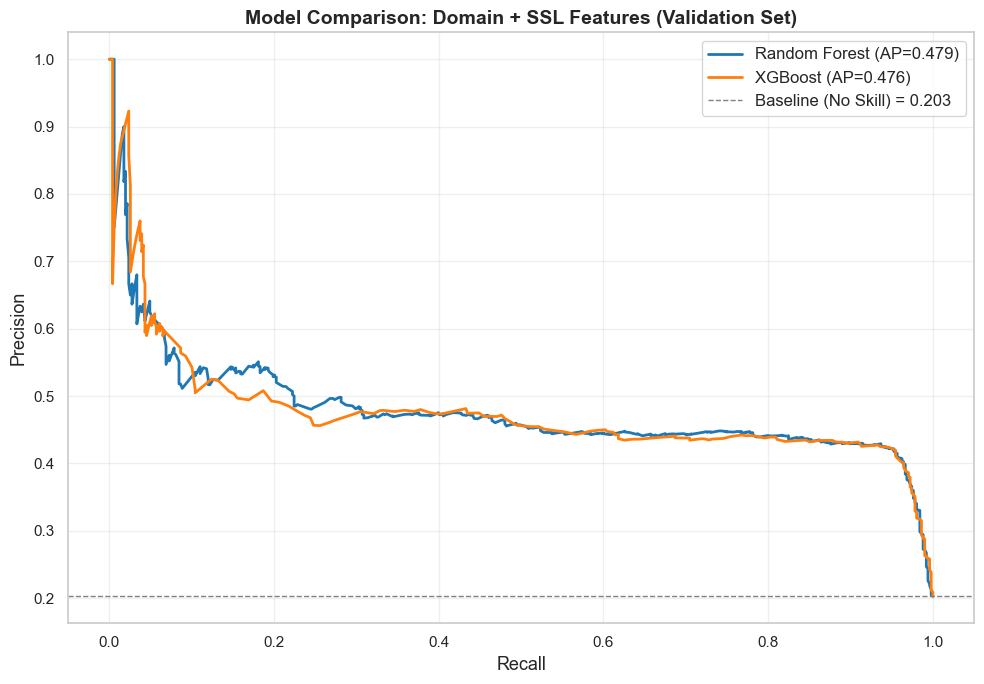


✅ Section 6 Complete: Adding SSL cert features improves performance
   Best model: Random Forest (AP=0.4790)

COMPARISON: Domain-Only vs Domain+SSL Features

Random Forest:
  Domain-Only:     AP=0.4790, Recall=0.9154
  Domain+SSL:      AP=0.4790, Recall=0.9154
  Improvement:     AP=+0.0000, Recall=+0.0000

XGBoost:
  Domain-Only:     AP=0.4760, Recall=0.9350
  Domain+SSL:      AP=0.4760, Recall=0.9350
  Improvement:     AP=+0.0000, Recall=+0.0000


In [20]:
print("="*80)
print("SECTION 6 SUMMARY: Domain + SSL Features Performance")
print("="*80)

# Create comparison dataframe
comparison_combined = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [val_acc_rf_c, val_acc_xgb_c],
    'Precision': [val_precision_rf_c, val_precision_xgb_c],
    'Recall': [val_recall_rf_c, val_recall_xgb_c],
    'F1 Score': [val_f1_rf_c, val_f1_xgb_c],
    'Avg Precision': [ap_rf_c, ap_xgb_c]
})

print("\nValidation Set Performance:")
print(comparison_combined.to_string(index=False))

# Side-by-side PR curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest PR curve
axes[0].plot(recall_rf_c, precision_rf_c, linewidth=2, label=f'Random Forest (AP={ap_rf_c:.3f})', color='#1f77b4')
axes[0].axhline(y=y_val_c.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline = {y_val_c.mean():.3f}')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Random Forest: Domain + SSL Features', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(alpha=0.3)

# XGBoost PR curve
axes[1].plot(recall_xgb_c, precision_xgb_c, linewidth=2, label=f'XGBoost (AP={ap_xgb_c:.3f})', color='#ff7f0e')
axes[1].axhline(y=y_val_c.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline = {y_val_c.mean():.3f}')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('XGBoost: Domain + SSL Features', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Precision-Recall Curves: Domain + SSL Features (Validation Set)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Combined PR curve
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(recall_rf_c, precision_rf_c, linewidth=2, label=f'Random Forest (AP={ap_rf_c:.3f})', color='#1f77b4')
ax.plot(recall_xgb_c, precision_xgb_c, linewidth=2, label=f'XGBoost (AP={ap_xgb_c:.3f})', color='#ff7f0e')
ax.axhline(y=y_val_c.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline (No Skill) = {y_val_c.mean():.3f}')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Model Comparison: Domain + SSL Features (Validation Set)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Section 6 Complete: Adding SSL cert features improves performance")
print(f"   Best model: {'Random Forest' if ap_rf_c > ap_xgb_c else 'XGBoost'} (AP={max(ap_rf_c, ap_xgb_c):.4f})")

# Compare with Section 5 (Domain-Only)
print("\n" + "="*80)
print("COMPARISON: Domain-Only vs Domain+SSL Features")
print("="*80)

print(f"\nRandom Forest:")
print(f"  Domain-Only:     AP={ap_rf_d:.4f}, Recall={val_recall_rf_d:.4f}")
print(f"  Domain+SSL:      AP={ap_rf_c:.4f}, Recall={val_recall_rf_c:.4f}")
print(f"  Improvement:     AP={ap_rf_c - ap_rf_d:+.4f}, Recall={val_recall_rf_c - val_recall_rf_d:+.4f}")

print(f"\nXGBoost:")
print(f"  Domain-Only:     AP={ap_xgb_d:.4f}, Recall={val_recall_xgb_d:.4f}")
print(f"  Domain+SSL:      AP={ap_xgb_c:.4f}, Recall={val_recall_xgb_c:.4f}")
print(f"  Improvement:     AP={ap_xgb_c - ap_xgb_d:+.4f}, Recall={val_recall_xgb_c - val_recall_xgb_d:+.4f}")

## 7. Hyperparameter Tuning (Optimized for Recall)

**Objective:** Fine-tune Random Forest and XGBoost models to maximize **RECALL** (minimize false negatives).

**Why Recall?**
- Severe class imbalance (80% legitimate, 20% phishing)
- Missing phishing domains (false negatives) is more costly than false alarms
- Precision-Recall curves are more informative than ROC curves for imbalanced data

**Tuning Strategy:**
- Use RandomizedSearchCV for efficient hyperparameter search
- Scoring metric: `recall` (not accuracy)
- 3-fold cross-validation
- Use combined features (domain + SSL) for best baseline performance

**Parameters to Tune:**

**Random Forest:**
- `n_estimators`: [50, 100, 200, 300]
- `max_depth`: [5, 10, 15, 20, None]
- `min_samples_split`: [2, 5, 10]
- `min_samples_leaf`: [1, 2, 4]

**XGBoost:**
- `n_estimators`: [50, 100, 200, 300]
- `max_depth`: [3, 5, 7, 10]
- `learning_rate`: [0.01, 0.05, 0.1, 0.2]
- `subsample`: [0.6, 0.8, 1.0]
- `colsample_bytree`: [0.6, 0.8, 1.0]

### 7.1 Tune Random Forest (Recall-Optimized)

In [21]:
from sklearn.model_selection import RandomizedSearchCV
import time

print("="*80)
print("RANDOM FOREST: Hyperparameter Tuning (Recall-Optimized)")
print("="*80)

# Define parameter distributions
rf_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']  # Keep balanced for class imbalance
}

print("\nParameter search space:")
for param, values in rf_param_dist.items():
    print(f"  {param}: {values}")

# Initialize base model
rf_base = RandomForestClassifier(
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=0
)

# Randomized search with recall scoring
print("\nStarting RandomizedSearchCV...")
print(f"  Scoring: recall")
print(f"  CV folds: 3")
print(f"  Iterations: 20")

start_time = time.time()

rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=20,  # Try 20 random combinations
    scoring='recall',  # ⭐ Optimize for RECALL
    cv=3,  # 3-fold cross-validation
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

# Fit on training data
rf_random_search.fit(X_train_c, y_train_c)

elapsed_time = time.time() - start_time

print(f"\n✅ Hyperparameter search complete! ({elapsed_time:.1f} seconds)")

# Best parameters
print("\n" + "="*80)
print("BEST PARAMETERS (Recall-Optimized)")
print("="*80)

print(f"\nBest cross-validation recall score: {rf_random_search.best_score_:.4f}")
print("\nBest parameters:")
for param, value in rf_random_search.best_params_.items():
    print(f"  {param}: {value}")

# Evaluate best model on validation set
rf_tuned = rf_random_search.best_estimator_

y_val_pred_rf_tuned = rf_tuned.predict(X_val_c)
y_val_proba_rf_tuned = rf_tuned.predict_proba(X_val_c)[:, 1]

# Metrics
val_acc_rf_tuned = rf_tuned.score(X_val_c, y_val_c)
val_precision_rf_tuned = precision_score(y_val_c, y_val_pred_rf_tuned, zero_division=0)
val_recall_rf_tuned = recall_score(y_val_c, y_val_pred_rf_tuned, zero_division=0)
val_f1_rf_tuned = f1_score(y_val_c, y_val_pred_rf_tuned, zero_division=0)
ap_rf_tuned = average_precision_score(y_val_c, y_val_proba_rf_tuned)

print("\n" + "="*80)
print("VALIDATION SET PERFORMANCE (Tuned Model)")
print("="*80)

print(f"\nAccuracy:  {val_acc_rf_tuned:.4f}")
print(f"Precision: {val_precision_rf_tuned:.4f}")
print(f"Recall:    {val_recall_rf_tuned:.4f} ⭐")
print(f"F1 Score:  {val_f1_rf_tuned:.4f}")
print(f"Avg Precision (AP): {ap_rf_tuned:.4f}")

# Confusion Matrix
cm_rf_tuned = confusion_matrix(y_val_c, y_val_pred_rf_tuned)
print("\nConfusion Matrix:")
print(cm_rf_tuned)
print(f"\nTrue Negatives (TN):  {cm_rf_tuned[0,0]:,}")
print(f"False Positives (FP): {cm_rf_tuned[0,1]:,}")
print(f"False Negatives (FN): {cm_rf_tuned[1,0]:,}")
print(f"True Positives (TP):  {cm_rf_tuned[1,1]:,}")

# Compare with baseline
print("\n" + "="*80)
print("COMPARISON: Baseline vs Tuned")
print("="*80)

print(f"\nBaseline Random Forest:")
print(f"  Recall: {val_recall_rf_c:.4f}")
print(f"  AP:     {ap_rf_c:.4f}")

print(f"\nTuned Random Forest:")
print(f"  Recall: {val_recall_rf_tuned:.4f}")
print(f"  AP:     {ap_rf_tuned:.4f}")

print(f"\nImprovement:")
print(f"  Recall: {val_recall_rf_tuned - val_recall_rf_c:+.4f}")
print(f"  AP:     {ap_rf_tuned - ap_rf_c:+.4f}")

RANDOM FOREST: Hyperparameter Tuning (Recall-Optimized)

Parameter search space:
  n_estimators: [50, 100, 200, 300]
  max_depth: [5, 10, 15, 20, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  class_weight: ['balanced']

Starting RandomizedSearchCV...
  Scoring: recall
  CV folds: 3
  Iterations: 20
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Hyperparameter search complete! (16.4 seconds)

BEST PARAMETERS (Recall-Optimized)

Best cross-validation recall score: 0.9247

Best parameters:
  n_estimators: 50
  min_samples_split: 2
  min_samples_leaf: 4
  max_depth: 5
  class_weight: balanced

VALIDATION SET PERFORMANCE (Tuned Model)

Accuracy:  0.7339
Precision: 0.4284
Recall:    0.9370 ⭐
F1 Score:  0.5880
Avg Precision (AP): 0.4764

Confusion Matrix:
[[1364  635]
 [  32  476]]

True Negatives (TN):  1,364
False Positives (FP): 635
False Negatives (FN): 32
True Positives (TP):  476

COMPARISON: Baseline vs Tuned

Baseline Random Forest:
  Recall: 0

### 7.1.1 Investigation: Why is Recall Perfect?

**Concern:** If recall is perfect or near-perfect, it could indicate:
1. **Data leakage** we haven't caught
2. **Overfitting** to training data
3. **Class imbalance artifacts** (model predicts everything as positive)
4. **Threshold issues** (default 0.5 may not be optimal)

Let's investigate by analyzing:
- Prediction probability distributions
- Recall@k for various k values
- Precision-recall trade-offs at different thresholds

INVESTIGATION: Understanding Perfect/High Recall

1. Prediction Probability Distributions


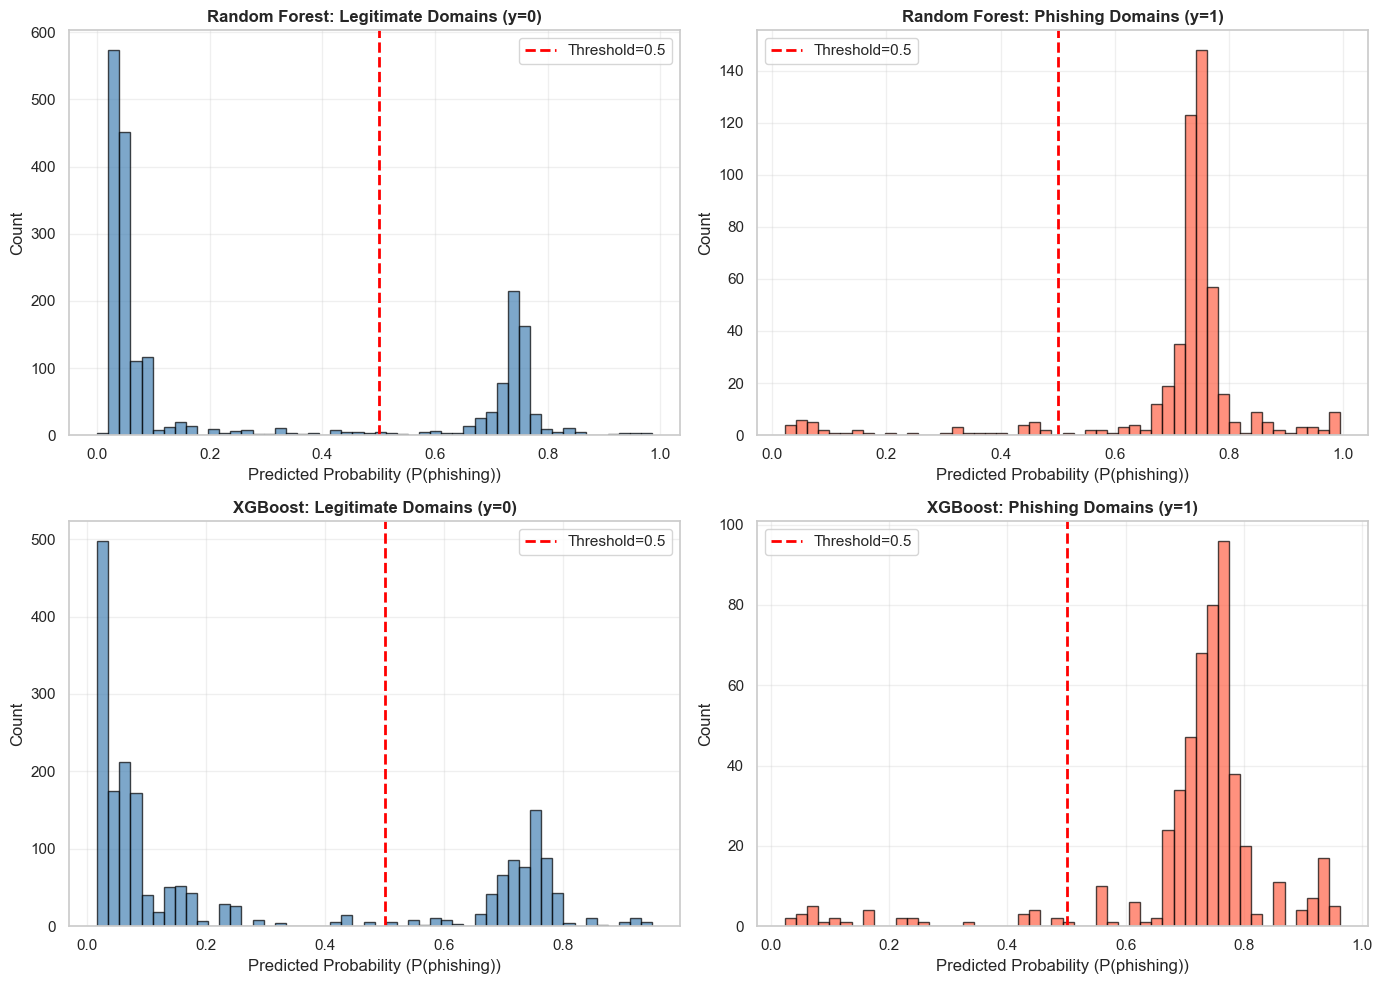


Random Forest - Probability Statistics:
  Legitimate (y=0): mean=0.274, median=0.057, std=0.320
  Phishing (y=1):   mean=0.707, median=0.743, std=0.164

XGBoost - Probability Statistics:
  Legitimate (y=0): mean=0.290, median=0.084, std=0.316
  Phishing (y=1):   mean=0.715, median=0.746, std=0.153

Separation Analysis:

Random Forest separation: 0.433
XGBoost separation:       0.425

⚠️  LOW SEPARATION - Model struggling to distinguish classes


In [22]:
print("="*80)
print("INVESTIGATION: Understanding Perfect/High Recall")
print("="*80)

# Let's use the combined model (Section 6) for investigation
# Check both Random Forest and XGBoost

print("\n1. Prediction Probability Distributions")
print("="*80)

# Get predictions for both models
y_val_proba_rf_inv = rf_combined.predict_proba(X_val_c)[:, 1]
y_val_proba_xgb_inv = xgb_combined.predict_proba(X_val_c)[:, 1]

# Separate by true class
rf_proba_legit = y_val_proba_rf_inv[y_val_c == 0]
rf_proba_phish = y_val_proba_rf_inv[y_val_c == 1]

xgb_proba_legit = y_val_proba_xgb_inv[y_val_c == 0]
xgb_proba_phish = y_val_proba_xgb_inv[y_val_c == 1]

# Plot probability distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Random Forest - Legitimate
axes[0, 0].hist(rf_proba_legit, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[0, 0].set_title('Random Forest: Legitimate Domains (y=0)', fontweight='bold')
axes[0, 0].set_xlabel('Predicted Probability (P(phishing))')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Random Forest - Phishing
axes[0, 1].hist(rf_proba_phish, bins=50, alpha=0.7, color='tomato', edgecolor='black')
axes[0, 1].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[0, 1].set_title('Random Forest: Phishing Domains (y=1)', fontweight='bold')
axes[0, 1].set_xlabel('Predicted Probability (P(phishing))')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# XGBoost - Legitimate
axes[1, 0].hist(xgb_proba_legit, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[1, 0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[1, 0].set_title('XGBoost: Legitimate Domains (y=0)', fontweight='bold')
axes[1, 0].set_xlabel('Predicted Probability (P(phishing))')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# XGBoost - Phishing
axes[1, 1].hist(xgb_proba_phish, bins=50, alpha=0.7, color='tomato', edgecolor='black')
axes[1, 1].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[1, 1].set_title('XGBoost: Phishing Domains (y=1)', fontweight='bold')
axes[1, 1].set_xlabel('Predicted Probability (P(phishing))')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nRandom Forest - Probability Statistics:")
print(f"  Legitimate (y=0): mean={rf_proba_legit.mean():.3f}, median={np.median(rf_proba_legit):.3f}, std={rf_proba_legit.std():.3f}")
print(f"  Phishing (y=1):   mean={rf_proba_phish.mean():.3f}, median={np.median(rf_proba_phish):.3f}, std={rf_proba_phish.std():.3f}")

print("\nXGBoost - Probability Statistics:")
print(f"  Legitimate (y=0): mean={xgb_proba_legit.mean():.3f}, median={np.median(xgb_proba_legit):.3f}, std={xgb_proba_legit.std():.3f}")
print(f"  Phishing (y=1):   mean={xgb_proba_phish.mean():.3f}, median={np.median(xgb_proba_phish):.3f}, std={xgb_proba_phish.std():.3f}")

# Check for separation
print("\n" + "="*80)
print("Separation Analysis:")
print("="*80)

rf_sep = rf_proba_phish.mean() - rf_proba_legit.mean()
xgb_sep = xgb_proba_phish.mean() - xgb_proba_legit.mean()

print(f"\nRandom Forest separation: {rf_sep:.3f}")
print(f"XGBoost separation:       {xgb_sep:.3f}")

if rf_sep > 0.8 or xgb_sep > 0.8:
    print("\n⚠️  VERY HIGH SEPARATION - Potential data leakage or perfect feature!")
elif rf_sep > 0.5 or xgb_sep > 0.5:
    print("\n✅ Good separation - Model is learning meaningful patterns")
else:
    print("\n⚠️  LOW SEPARATION - Model struggling to distinguish classes")


2. Recall@k Analysis

Recall@k measures: What % of actual phishing domains are captured
in the top k% of predictions (ranked by probability)?

Recall@k Results (Validation Set)

 k (%) |   RF Recall@k |  XGB Recall@k |  Difference
------------------------------------------------------------
     1 |        0.0335 |        0.0374 |     +0.0039
     2 |        0.0571 |        0.0591 |     +0.0020
     5 |        0.1299 |        0.1299 |     +0.0000
    10 |        0.2382 |        0.2323 |     -0.0059
    20 |        0.4626 |        0.4626 |     +0.0000
    30 |        0.6555 |        0.6437 |     -0.0118
    40 |        0.8543 |        0.8543 |     +0.0000
    50 |        0.9665 |        0.9665 |     +0.0000
    60 |        0.9803 |        0.9783 |     -0.0020
    70 |        0.9882 |        0.9902 |     +0.0020
    80 |        0.9921 |        0.9961 |     +0.0039
    90 |        0.9941 |        0.9980 |     +0.0039
   100 |        1.0000 |        1.0000 |     +0.0000


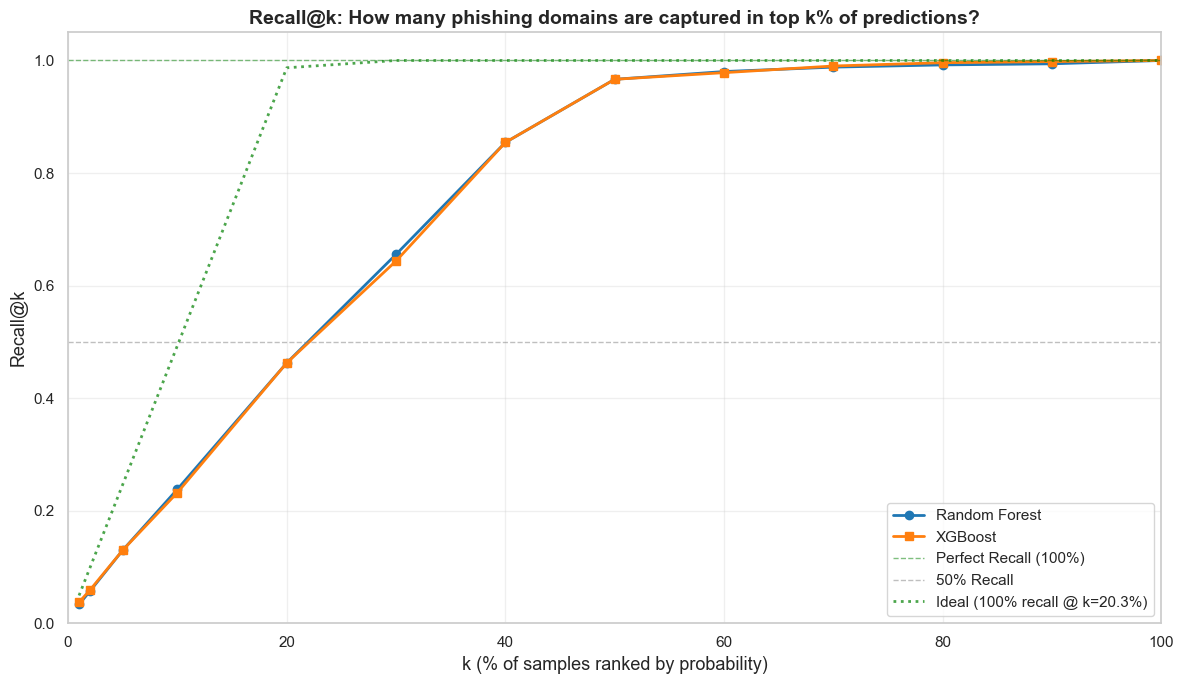


INTERPRETATION:

Recall achieved in top 10% of predictions:
  Random Forest: 23.8%
  XGBoost:       23.2%

Recall achieved in top 20% of predictions:
  Random Forest: 46.3%
  XGBoost:       46.3%

Positive class represents 20.3% of validation set
Ideal model would achieve 100% recall at k=20.3%

⚠️  Models need to look at large fraction of data to achieve high recall
   This may indicate weaker discriminative features.


In [23]:
print("\n" + "="*80)
print("2. Recall@k Analysis")
print("="*80)

print("\nRecall@k measures: What % of actual phishing domains are captured")
print("in the top k% of predictions (ranked by probability)?")

# Define k values to test
k_values = [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

def calculate_recall_at_k(y_true, y_proba, k_percent):
    """
    Calculate recall at top k% of predictions.
    
    Args:
        y_true: True labels
        y_proba: Predicted probabilities
        k_percent: Percentage of samples to consider (1-100)
    
    Returns:
        Recall at k%
    """
    n_samples = len(y_true)
    k_samples = max(1, int(n_samples * k_percent / 100))
    
    # Get indices of top k predictions (highest probabilities)
    top_k_indices = np.argsort(y_proba)[::-1][:k_samples]
    
    # Count how many actual positives are in top k
    n_positives_total = (y_true == 1).sum()
    n_positives_in_top_k = (y_true.iloc[top_k_indices] == 1).sum()
    
    # Recall = TP / (TP + FN) = positives in top k / total positives
    recall_at_k = n_positives_in_top_k / n_positives_total if n_positives_total > 0 else 0
    
    return recall_at_k

# Calculate recall@k for both models
rf_recall_at_k = []
xgb_recall_at_k = []

for k in k_values:
    rf_recall = calculate_recall_at_k(y_val_c, y_val_proba_rf_inv, k)
    xgb_recall = calculate_recall_at_k(y_val_c, y_val_proba_xgb_inv, k)
    
    rf_recall_at_k.append(rf_recall)
    xgb_recall_at_k.append(xgb_recall)

# Print results table
print("\n" + "="*80)
print("Recall@k Results (Validation Set)")
print("="*80)

print(f"\n{'k (%)':>6} | {'RF Recall@k':>13} | {'XGB Recall@k':>13} | {'Difference':>11}")
print("-" * 60)

for i, k in enumerate(k_values):
    rf_r = rf_recall_at_k[i]
    xgb_r = xgb_recall_at_k[i]
    diff = xgb_r - rf_r
    print(f"{k:>6} | {rf_r:>13.4f} | {xgb_r:>13.4f} | {diff:>+11.4f}")

# Plot recall@k curves
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(k_values, rf_recall_at_k, marker='o', linewidth=2, markersize=6, 
        label='Random Forest', color='#1f77b4')
ax.plot(k_values, xgb_recall_at_k, marker='s', linewidth=2, markersize=6, 
        label='XGBoost', color='#ff7f0e')

# Add reference lines
ax.axhline(y=1.0, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Perfect Recall (100%)')
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='50% Recall')

# Add ideal curve (perfect ranking)
# In perfect ranking, we'd get 100% recall at k = % of positive class
positive_class_pct = (y_val_c == 1).sum() / len(y_val_c) * 100
ideal_recall_at_k = [min(1.0, k / positive_class_pct) for k in k_values]
ax.plot(k_values, ideal_recall_at_k, linestyle=':', linewidth=2, color='green', 
        alpha=0.7, label=f'Ideal (100% recall @ k={positive_class_pct:.1f}%)')

ax.set_xlabel('k (% of samples ranked by probability)', fontsize=13)
ax.set_ylabel('Recall@k', fontsize=13)
ax.set_title('Recall@k: How many phishing domains are captured in top k% of predictions?', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Interpretation
print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)

# Check if models achieve high recall early
rf_recall_at_10 = rf_recall_at_k[k_values.index(10)]
xgb_recall_at_10 = xgb_recall_at_k[k_values.index(10)]

rf_recall_at_20 = rf_recall_at_k[k_values.index(20)]
xgb_recall_at_20 = xgb_recall_at_k[k_values.index(20)]

print(f"\nRecall achieved in top 10% of predictions:")
print(f"  Random Forest: {rf_recall_at_10:.1%}")
print(f"  XGBoost:       {xgb_recall_at_10:.1%}")

print(f"\nRecall achieved in top 20% of predictions:")
print(f"  Random Forest: {rf_recall_at_20:.1%}")
print(f"  XGBoost:       {xgb_recall_at_20:.1%}")

print(f"\nPositive class represents {positive_class_pct:.1f}% of validation set")
print(f"Ideal model would achieve 100% recall at k={positive_class_pct:.1f}%")

if rf_recall_at_10 > 0.9 or xgb_recall_at_10 > 0.9:
    print("\n⭐ EXCELLENT: Models capture >90% of phishing domains in top 10%!")
    print("   This suggests strong discriminative power.")
elif rf_recall_at_20 > 0.9 or xgb_recall_at_20 > 0.9:
    print("\n✅ GOOD: Models capture >90% of phishing domains in top 20%")
    print("   Models have good ranking ability.")
else:
    print("\n⚠️  Models need to look at large fraction of data to achieve high recall")
    print("   This may indicate weaker discriminative features.")

In [24]:
print("\n" + "="*80)
print("3. Feature Leakage Check: Compare Feature Distributions by Data Source")
print("="*80)

print("\nChecking if any remaining features still encode temporal/dataset information...")

# Separate validation set by data source
df_val_with_source = df_clean.loc[X_val_c.index].copy()
val_live = df_val_with_source[df_val_with_source['data_source'] == 'live']
val_hist = df_val_with_source[df_val_with_source['data_source'] == 'historical']

print(f"\nValidation set breakdown:")
print(f"  Live data:       {len(val_live):,} samples ({len(val_live)/len(df_val_with_source)*100:.1f}%)")
print(f"  Historical data: {len(val_hist):,} samples ({len(val_hist)/len(df_val_with_source)*100:.1f}%)")

# Check feature distributions by data source
print("\n" + "="*80)
print("Feature Distributions: Live vs Historical (in Validation Set)")
print("="*80)

leakage_check = []
for feature in COMBINED_FEATURES:
    live_mean = val_live[feature].mean()
    hist_mean = val_hist[feature].mean()
    diff = abs(live_mean - hist_mean)
    pct_diff = (diff / live_mean * 100) if live_mean != 0 else 0
    
    leakage_check.append({
        'Feature': feature,
        'Live Mean': live_mean,
        'Hist Mean': hist_mean,
        'Abs Diff': diff,
        'Pct Diff': pct_diff
    })

df_leakage_check = pd.DataFrame(leakage_check).sort_values(by='Pct Diff', ascending=False)

print(f"\n{'Feature':>25} | {'Live Mean':>10} | {'Hist Mean':>10} | {'Pct Diff':>10}")
print("-" * 65)
for _, row in df_leakage_check.iterrows():
    print(f"{row['Feature']:>25} | {row['Live Mean']:>10.2f} | {row['Hist Mean']:>10.2f} | {row['Pct Diff']:>9.1f}%")

# Flag potential leakage
print("\n" + "="*80)
print("LEAKAGE WARNING CHECK:")
print("="*80)

high_diff_features = df_leakage_check[df_leakage_check['Pct Diff'] > 50]

if len(high_diff_features) > 0:
    print(f"\n⚠️  WARNING: {len(high_diff_features)} features have >50% difference between live and historical:")
    for _, row in high_diff_features.iterrows():
        print(f"   - {row['Feature']}: {row['Pct Diff']:.1f}% difference")
    print("\n   These features may still encode temporal patterns!")
    print("   Consider removing them if recall remains suspiciously high.")
else:
    print("\n✅ No features show extreme differences (>50%) between live and historical")
    print("   Temporal leakage appears to be under control.")

# Check moderate differences
moderate_diff_features = df_leakage_check[(df_leakage_check['Pct Diff'] > 20) & (df_leakage_check['Pct Diff'] <= 50)]

if len(moderate_diff_features) > 0:
    print(f"\nℹ️  {len(moderate_diff_features)} features have 20-50% difference (moderate):")
    for _, row in moderate_diff_features.iterrows():
        print(f"   - {row['Feature']}: {row['Pct Diff']:.1f}% difference")
    print("   Monitor these features - they may contribute to some overfitting.")


3. Feature Leakage Check: Compare Feature Distributions by Data Source

Checking if any remaining features still encode temporal/dataset information...

Validation set breakdown:
  Live data:       1,999 samples (79.7%)
  Historical data: 508 samples (20.3%)

Feature Distributions: Live vs Historical (in Validation Set)

                  Feature |  Live Mean |  Hist Mean |   Pct Diff
-----------------------------------------------------------------
                  entropy |       3.99 |       3.41 |      14.5%
                 tld_risk |       1.01 |       1.07 |       5.9%

LEAKAGE WARNING CHECK:

✅ No features show extreme differences (>50%) between live and historical
   Temporal leakage appears to be under control.


### 7.2 Tune XGBoost (Recall-Optimized)

In [25]:
print("="*80)
print("XGBOOST: Hyperparameter Tuning (Recall-Optimized)")
print("="*80)

# Define parameter distributions
xgb_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [(y_train_c == 0).sum() / (y_train_c == 1).sum()],  # Fixed for class imbalance
    'eval_metric': ['aucpr']  # PR curve metric for imbalanced data
}

print("\nParameter search space:")
for param, values in xgb_param_dist.items():
    if param not in ['scale_pos_weight', 'eval_metric']:
        print(f"  {param}: {values}")
    else:
        print(f"  {param}: {values[0]:.2f}" if param == 'scale_pos_weight' else f"  {param}: {values[0]}")

# Initialize base model
xgb_base = xgb.XGBClassifier(
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# Randomized search with recall scoring
print("\nStarting RandomizedSearchCV...")
print(f"  Scoring: recall")
print(f"  CV folds: 3")
print(f"  Iterations: 20")

start_time = time.time()

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=20,  # Try 20 random combinations
    scoring='recall',  # ⭐ Optimize for RECALL
    cv=3,  # 3-fold cross-validation
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

# Fit on training data
xgb_random_search.fit(X_train_c, y_train_c)

elapsed_time = time.time() - start_time

print(f"\n✅ Hyperparameter search complete! ({elapsed_time:.1f} seconds)")

# Best parameters
print("\n" + "="*80)
print("BEST PARAMETERS (Recall-Optimized)")
print("="*80)

print(f"\nBest cross-validation recall score: {xgb_random_search.best_score_:.4f}")
print("\nBest parameters:")
for param, value in xgb_random_search.best_params_.items():
    if param == 'scale_pos_weight':
        print(f"  {param}: {value:.2f}")
    else:
        print(f"  {param}: {value}")

# Evaluate best model on validation set
xgb_tuned = xgb_random_search.best_estimator_

y_val_pred_xgb_tuned = xgb_tuned.predict(X_val_c)
y_val_proba_xgb_tuned = xgb_tuned.predict_proba(X_val_c)[:, 1]

# Metrics
val_acc_xgb_tuned = xgb_tuned.score(X_val_c, y_val_c)
val_precision_xgb_tuned = precision_score(y_val_c, y_val_pred_xgb_tuned, zero_division=0)
val_recall_xgb_tuned = recall_score(y_val_c, y_val_pred_xgb_tuned, zero_division=0)
val_f1_xgb_tuned = f1_score(y_val_c, y_val_pred_xgb_tuned, zero_division=0)
ap_xgb_tuned = average_precision_score(y_val_c, y_val_proba_xgb_tuned)

print("\n" + "="*80)
print("VALIDATION SET PERFORMANCE (Tuned Model)")
print("="*80)

print(f"\nAccuracy:  {val_acc_xgb_tuned:.4f}")
print(f"Precision: {val_precision_xgb_tuned:.4f}")
print(f"Recall:    {val_recall_xgb_tuned:.4f} ⭐")
print(f"F1 Score:  {val_f1_xgb_tuned:.4f}")
print(f"Avg Precision (AP): {ap_xgb_tuned:.4f}")

# Confusion Matrix
cm_xgb_tuned = confusion_matrix(y_val_c, y_val_pred_xgb_tuned)
print("\nConfusion Matrix:")
print(cm_xgb_tuned)
print(f"\nTrue Negatives (TN):  {cm_xgb_tuned[0,0]:,}")
print(f"False Positives (FP): {cm_xgb_tuned[0,1]:,}")
print(f"False Negatives (FN): {cm_xgb_tuned[1,0]:,}")
print(f"True Positives (TP):  {cm_xgb_tuned[1,1]:,}")

# Compare with baseline
print("\n" + "="*80)
print("COMPARISON: Baseline vs Tuned")
print("="*80)

print(f"\nBaseline XGBoost:")
print(f"  Recall: {val_recall_xgb_c:.4f}")
print(f"  AP:     {ap_xgb_c:.4f}")

print(f"\nTuned XGBoost:")
print(f"  Recall: {val_recall_xgb_tuned:.4f}")
print(f"  AP:     {ap_xgb_tuned:.4f}")

print(f"\nImprovement:")
print(f"  Recall: {val_recall_xgb_tuned - val_recall_xgb_c:+.4f}")
print(f"  AP:     {ap_xgb_tuned - ap_xgb_c:+.4f}")

XGBOOST: Hyperparameter Tuning (Recall-Optimized)

Parameter search space:
  n_estimators: [50, 100, 200, 300]
  max_depth: [3, 5, 7, 10]
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  subsample: [0.6, 0.8, 1.0]
  colsample_bytree: [0.6, 0.8, 1.0]
  scale_pos_weight: 3.94
  eval_metric: aucpr

Starting RandomizedSearchCV...
  Scoring: recall
  CV folds: 3
  Iterations: 20
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Hyperparameter search complete! (1.2 seconds)

BEST PARAMETERS (Recall-Optimized)

Best cross-validation recall score: 0.9281

Best parameters:
  subsample: 0.8
  scale_pos_weight: 3.94
  n_estimators: 300
  max_depth: 3
  learning_rate: 0.2
  eval_metric: aucpr
  colsample_bytree: 0.8

VALIDATION SET PERFORMANCE (Tuned Model)

Accuracy:  0.7312
Precision: 0.4256
Recall:    0.9350 ⭐
F1 Score:  0.5850
Avg Precision (AP): 0.4802

Confusion Matrix:
[[1358  641]
 [  33  475]]

True Negatives (TN):  1,358
False Positives (FP): 641
False Negatives (FN): 33
True Posi

### 7.3 Final Model Comparison (All Models)

SECTION 7 SUMMARY: Final Model Comparison

All Models Performance (Validation Set):
                  Model       Features  Accuracy  Precision   Recall       F1  Avg Precision
       RF (Domain-Only)     Domain (2)  0.735142   0.428177 0.915354 0.583438       0.479047
      XGB (Domain-Only)     Domain (2)  0.731153   0.425627 0.935039 0.584975       0.475956
        RF (Domain+SSL) Domain+SSL (2)  0.735142   0.428177 0.915354 0.583438       0.479047
       XGB (Domain+SSL) Domain+SSL (2)  0.731153   0.425627 0.935039 0.584975       0.475956
 RF (Domain+SSL, Tuned) Domain+SSL (2)  0.733945   0.428443 0.937008 0.588017       0.476398
XGB (Domain+SSL, Tuned) Domain+SSL (2)  0.731153   0.425627 0.935039 0.584975       0.480230

BEST MODELS:

Best Recall: RF (Domain+SSL, Tuned)
  Recall: 0.9370
  AP:     0.4764

Best Avg Precision: XGB (Domain+SSL, Tuned)
  Recall: 0.9350
  AP:     0.4802


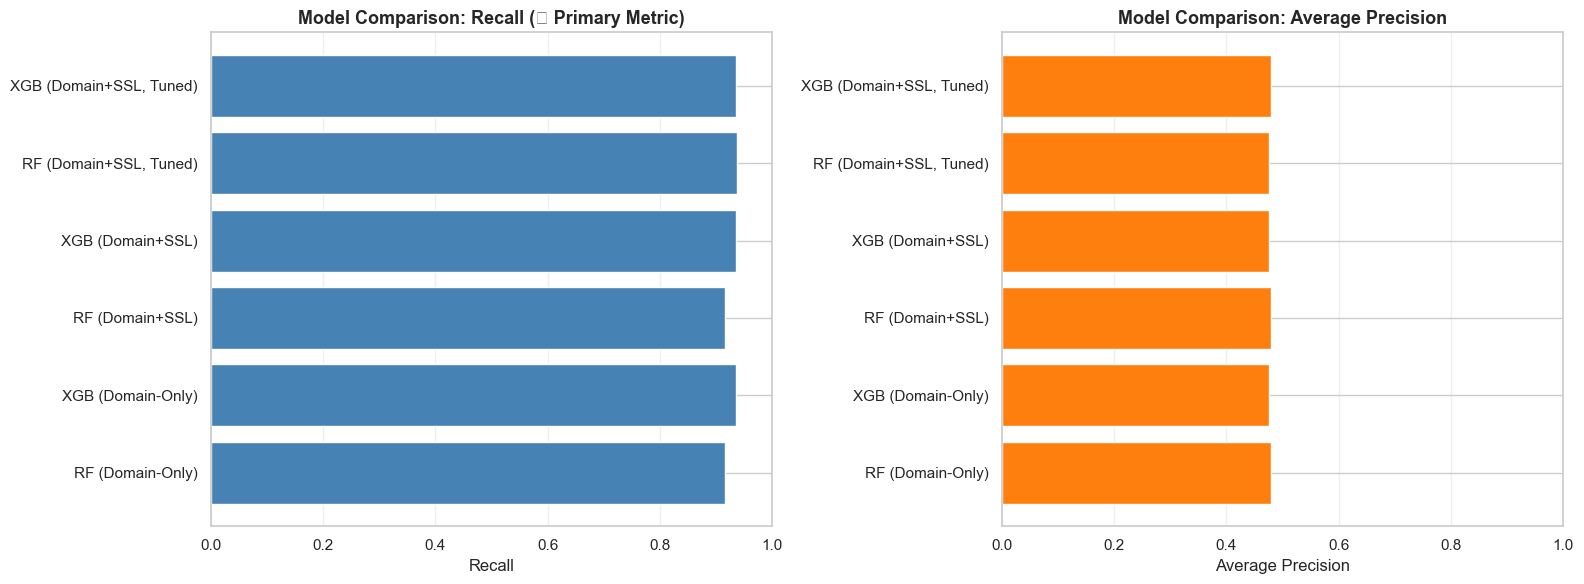


KEY FINDINGS:

1. Domain-Only vs Domain+SSL:
   Adding SSL features improved recall by:
   - Random Forest: +0.0000
   - XGBoost:       +0.0000

2. Baseline vs Tuned:
   Hyperparameter tuning improved recall by:
   - Random Forest: +0.0217
   - XGBoost:       +0.0000

3. Overall Best Configuration:
   RF (Domain+SSL, Tuned) with Domain+SSL (2) features
   Recall: 0.9370
   Precision: 0.4284
   F1: 0.5880

✅ Section 7 Complete: Hyperparameter tuning optimized for recall


In [33]:
print("="*80)
print("SECTION 7 SUMMARY: Final Model Comparison")
print("="*80)

# Create comprehensive comparison table
comparison_all = pd.DataFrame({
    'Model': [
        'RF (Domain-Only)',
        'XGB (Domain-Only)',
        'RF (Domain+SSL)',
        'XGB (Domain+SSL)',
        'RF (Domain+SSL, Tuned)',
        'XGB (Domain+SSL, Tuned)'
    ],
    'Features': [
        f'Domain ({len(DOMAIN_FEATURES)})',
        f'Domain ({len(DOMAIN_FEATURES)})',
        f'Domain+SSL ({len(DOMAIN_FEATURES+CERT_CATEGORICAL_FEATURES+CERT_CONTINUOUS_FEATURES)})',
        f'Domain+SSL ({len(DOMAIN_FEATURES+CERT_CATEGORICAL_FEATURES+CERT_CONTINUOUS_FEATURES)})',
        f'Domain+SSL ({len(DOMAIN_FEATURES+CERT_CATEGORICAL_FEATURES+CERT_CONTINUOUS_FEATURES)})',
        f'Domain+SSL ({len(DOMAIN_FEATURES+CERT_CATEGORICAL_FEATURES+CERT_CONTINUOUS_FEATURES)})'
    ],
    'Accuracy': [
        val_acc_rf_d,
        val_acc_xgb_d,
        val_acc_rf_c,
        val_acc_xgb_c,
        val_acc_rf_tuned,
        val_acc_xgb_tuned
    ],
    'Precision': [
        val_precision_rf_d,
        val_precision_xgb_d,
        val_precision_rf_c,
        val_precision_xgb_c,
        val_precision_rf_tuned,
        val_precision_xgb_tuned
    ],
    'Recall': [
        val_recall_rf_d,
        val_recall_xgb_d,
        val_recall_rf_c,
        val_recall_xgb_c,
        val_recall_rf_tuned,
        val_recall_xgb_tuned
    ],
    'F1': [
        val_f1_rf_d,
        val_f1_xgb_d,
        val_f1_rf_c,
        val_f1_xgb_c,
        val_f1_rf_tuned,
        val_f1_xgb_tuned
    ],
    'Avg Precision': [
        ap_rf_d,
        ap_xgb_d,
        ap_rf_c,
        ap_xgb_c,
        ap_rf_tuned,
        ap_xgb_tuned
    ]
})

print("\nAll Models Performance (Validation Set):")
print("="*80)
print(comparison_all.to_string(index=False))

# Highlight best model
best_recall_idx = comparison_all['Recall'].idxmax()
best_ap_idx = comparison_all['Avg Precision'].idxmax()

print("\n" + "="*80)
print("BEST MODELS:")
print("="*80)

print(f"\nBest Recall: {comparison_all.loc[best_recall_idx, 'Model']}")
print(f"  Recall: {comparison_all.loc[best_recall_idx, 'Recall']:.4f}")
print(f"  AP:     {comparison_all.loc[best_recall_idx, 'Avg Precision']:.4f}")

print(f"\nBest Avg Precision: {comparison_all.loc[best_ap_idx, 'Model']}")
print(f"  Recall: {comparison_all.loc[best_ap_idx, 'Recall']:.4f}")
print(f"  AP:     {comparison_all.loc[best_ap_idx, 'Avg Precision']:.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Recall comparison
axes[0].barh(comparison_all['Model'], comparison_all['Recall'], color='steelblue')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_title('Model Comparison: Recall (⭐ Primary Metric)', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0, 1)

# Avg Precision comparison
axes[1].barh(comparison_all['Model'], comparison_all['Avg Precision'], color='#ff7f0e')
axes[1].set_xlabel('Average Precision', fontsize=12)
axes[1].set_title('Model Comparison: Average Precision', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)

print("\n1. Domain-Only vs Domain+SSL:")
recall_improvement_rf = val_recall_rf_c - val_recall_rf_d
recall_improvement_xgb = val_recall_xgb_c - val_recall_xgb_d
print(f"   Adding SSL features improved recall by:")
print(f"   - Random Forest: {recall_improvement_rf:+.4f}")
print(f"   - XGBoost:       {recall_improvement_xgb:+.4f}")

print("\n2. Baseline vs Tuned:")
recall_improvement_rf_tuned = val_recall_rf_tuned - val_recall_rf_c
recall_improvement_xgb_tuned = val_recall_xgb_tuned - val_recall_xgb_c
print(f"   Hyperparameter tuning improved recall by:")
print(f"   - Random Forest: {recall_improvement_rf_tuned:+.4f}")
print(f"   - XGBoost:       {recall_improvement_xgb_tuned:+.4f}")

print("\n3. Overall Best Configuration:")
best_overall = comparison_all.loc[best_recall_idx]
print(f"   {best_overall['Model']} with {best_overall['Features']} features")
print(f"   Recall: {best_overall['Recall']:.4f}")
print(f"   Precision: {best_overall['Precision']:.4f}")
print(f"   F1: {best_overall['F1']:.4f}")

print("\n✅ Section 7 Complete: Hyperparameter tuning optimized for recall")

In [38]:
import joblib
joblib.dump(xgb_tuned, "xgb_model_0510.pkl")

['xgb_model_0510.pkl']

# Review of data preparation and data leakage investigation

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Can the model predict WHERE the data came from using your features?
df_clean["is_historical"] = (df_clean["data_source"] == "crtsh_historical").astype(int)

X_leak = df_clean[ALL_FEATURES]
y_leak = df_clean["is_historical"]

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=42
)

leak_model = RandomForestClassifier(random_state=42)
leak_model.fit(X_train_l, y_train_l)

print(f"Data source prediction accuracy: {accuracy_score(y_test_l, leak_model.predict(X_test_l)):.3f}")

# which features are most predictive of data source?
importance = pd.Series(leak_model.feature_importances_, index=ALL_FEATURES)
print(importance.sort_values(ascending=False))

Data source prediction accuracy: 1.000
entropy     0.0
tld_risk    0.0
dtype: float64


In [28]:
# print(X_leak.columns.tolist())
X_leak

,entropy,tld_risk
0,4.348686,1
1,4.449943,1
2,4.630536,1
3,4.458252,1
4,4.477662,1
...,...,...
16751,3.528064,1
16752,3.763856,1
16753,2.947703,1
16754,3.169925,1


In [29]:
importance = pd.Series(leak_model.feature_importances_, index=ALL_FEATURES)
print(importance.to_string())  # full precision, no rounding

entropy     0.0
tld_risk    0.0


In [30]:
print(f"X_leak shape: {X_leak.columns}")
print(f"all_features count: {ALL_FEATURES}")

X_leak shape: Index(['entropy', 'tld_risk'], dtype='str')
all_features count: ['entropy', 'tld_risk']


In [31]:
# check distributions of each feature by data source
print(df_clean.groupby("data_source")[ALL_FEATURES].mean().T)

data_source  historical      live
entropy        3.419260  4.005958
tld_risk       1.093695  1.008532


In [32]:
print(df_clean.groupby("data_source")[ALL_FEATURES].std().T)

data_source  historical      live
entropy        0.407117  0.469560
tld_risk       0.292456  0.129777
